This code loops through sessions containing Patch Foraging and FIP towards assembling a concatenated cross-session data table.

In [130]:
##Imports + config

from aind_vr_foraging_analysis.utils.parsing import parse, data_access
import aind_vr_foraging_analysis.utils.plotting as plotting

# Plotting libraries
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import seaborn as sns
import pandas as pd
import numpy as np
import pytz
from datetime import datetime
sns.set_context('talk')

import warnings
pd.options.mode.chained_assignment = None  # Ignore SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
from pathlib import Path
import os, glob, csv, json, re
import numpy as np
import pandas as pd

import PreprocessingFunctions_v2 as pf

from aind_vr_foraging_analysis.utils.parsing import parse, data_access

# Function to assign codes
def get_condition_code(text):
    if 'delayed' in text:
        return 'D'
    elif 'single' in text:
        return 'S'
    elif 'no_reward' in text or 'noreward' in text:
        return 'N'
    elif 'double' in text:
        return 'Do'
    else:
        return text

# -------------------------
# FIP preprocessing params
# -------------------------
nFrame2cut   = 100
sampling_rate = 20     # Hz per channel
kernelSize   = 1
degree       = 4
b_percentile = 0.70

# Keep file size reasonable
Roi2Vis = None       # or None for all ROIs

# Align/export settings
ALIGN_LABELS = ["OdorSite","InterSite","InterPatch"]   
T_PRE  = 4.0
T_POST = 4.0

# Output
OUTDIR = Path(r"Z:\jason.lee\patch_foraging\Data\multisession_tables")
OUTDIR.mkdir(parents=True, exist_ok=True)


In [131]:
##FIP loader

def load_fip_preprocess(FIP_Dir: Path,
                        nFrame2cut=100, sampling_rate=20,
                        kernelSize=1, degree=4, b_percentile=0.70):
    """
    Returns:
      time_seconds: (T,)
      Ctrl_dF_F, G_dF_F, R_dF_F: (T, n_rois)
    """
    FIP_Dir = Path(FIP_Dir)
    try:
        file1 = glob.glob(str(FIP_Dir / "FIP_DataIso_*"))[0]
    except Exception:
        file1 = glob.glob(str(FIP_Dir / "iso.csv"))[0]
        file2 = glob.glob(str(FIP_Dir / "green.csv"))[0]
        file3 = glob.glob(str(FIP_Dir / "red.csv"))[0]
    else:
        file2 = glob.glob(str(FIP_Dir / "green.csv"))[0]
        file3 = glob.glob(str(FIP_Dir / "red.csv"))[0]

    def _read_csv_float64(fp):
        with open(fp) as f:
            reader = csv.reader(f)
            datatemp = np.array([row for row in reader])
        return datatemp[1:, :].astype(np.float64)

    data1 = _read_csv_float64(file1)  # iso
    data2 = _read_csv_float64(file2)  # green
    data3 = _read_csv_float64(file3)  # red (or stim in some conventions)

    # truncate to common length
    L = np.amin([len(data1), len(data2), len(data3)])
    data1, data2, data3 = data1[:L], data2[:L], data3[:L]

    time_seconds = np.arange(L, dtype=float) / float(sampling_rate)

    PMts = data2[:,0].astype(float)

    # Allocate: use only ROI columns (you store in first columns too, but you fill [:, ii])
    # uses shape (T, data1.shape[1]) but fills only first n_rois.
    n_cols = data1.shape[1]
    Ctrl_dF_F = np.zeros((L, n_cols), dtype=float)
    G_dF_F    = np.zeros((L, n_cols), dtype=float)
    R_dF_F    = np.zeros((L, n_cols), dtype=float)

    # skip first 4 columns; fibers are cols 4-7 (0-index: 4..)
    n_rois = data2.shape[1] - 4
    for ii in range(n_rois):
        Ctrl_dF_F[:, ii] = pf.tc_preprocess(data1[:, ii+4], nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)
        G_dF_F[:, ii]    = pf.tc_preprocess(data2[:, ii+4], nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)
        R_dF_F[:, ii]    = pf.tc_preprocess(data3[:, ii+4], nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)

    # Trim to actual ROI count for cleanliness
    Ctrl_dF_F = Ctrl_dF_F[:, :n_rois]
    G_dF_F    = G_dF_F[:, :n_rois]
    R_dF_F    = R_dF_F[:, :n_rois]

    return PMts, time_seconds, Ctrl_dF_F, G_dF_F, R_dF_F

In [132]:
#Alignment + Long table builder

def _extract_window_fixed(y_1d, center_idx, pre_frames, post_frames):
    L = pre_frames + post_frames + 1
    out = np.full(L, np.nan, dtype=float)
    start = center_idx - pre_frames
    end   = center_idx + post_frames + 1

    src_start = max(start, 0)
    src_end   = min(end, len(y_1d))
    dst_start = src_start - start
    dst_end   = dst_start + (src_end - src_start)

    out[dst_start:dst_end] = y_1d[src_start:src_end].astype(float)
    return out

def build_session_aligned_long(all_epochs: pd.DataFrame,
                               time_seconds: np.ndarray,
                               Ctrl_dF_F: np.ndarray,
                               G_dF_F: np.ndarray,
                               R_dF_F: np.ndarray,
                               mouse: str,
                               session_id: str,
                               align_labels=("OdorSite",),
                               align_time_col="epoch_time",
                               extra_filter=None,          # function(df)->mask or None
                               t_pre=2.0,
                               t_post=5.0,
                               rois=None,
                               sampling_rate=20,
                               baseline_window=(-2.0, 0.0),
                               add_value_bs=True,
                               add_value_z=True,
                               zscore_mode="baseline"
                               ):
    """
    Returns:
      epochs_df: all_epochs with ids + epoch_time column
      aligned_long: long table for selected align_labels
    """
    epochs_df = all_epochs.copy()
    epochs_df = all_epochs.reset_index()
    # Whatever the first column is after reset_index() is the old index
    idx_col = epochs_df.columns[0]
    epochs_df = epochs_df.rename(columns={idx_col: "epoch_time"})

    epochs_df['mouse'] = str(mouse)
    epochs_df['session_id'] = str(session_id)
    epochs_df['epoch_id'] = (
        epochs_df['mouse'].astype(str) + "_" +
        epochs_df['session_id'].astype(str) + "_" +
        epochs_df.index.astype(str)
    )

    pre_frames  = int(round(t_pre * sampling_rate))
    post_frames = int(round(t_post * sampling_rate))
    t_rel = (np.arange(-pre_frames, post_frames + 1) / sampling_rate).astype(float)

    b0, b1 = baseline_window
    base_mask = (t_rel >= b0) & (t_rel < b1)


    n_rois = Ctrl_dF_F.shape[1]
    if rois is None:
        rois = list(range(n_rois))

    chan_map = {'Ctrl': Ctrl_dF_F, 'G': G_dF_F, 'R': R_dF_F}

    all_rows = []
    for align_label in align_labels:
        mask = epochs_df['label'].eq(align_label)
        if extra_filter is not None:
            mask &= extra_filter(epochs_df)

        align_df = epochs_df.loc[mask].copy()

        # if aligning by reward_onset_time (or any other col), drop rows where it's missing
        align_df = align_df.dropna(subset=[align_time_col])

        if align_df.empty:
            continue


        # QC: epoch times inside range?
        tmin, tmax = float(np.nanmin(align_df['epoch_time'])), float(np.nanmax(align_df['epoch_time']))
        if tmin < -1e-3 or tmax > float(time_seconds[-1]) + 1e-3:
            # still proceed, but many windows may pad NaNs
            pass

        # time -> nearest frame (uniform fs)
        times = align_df[align_time_col].astype(float).to_numpy()
        center_idx = np.searchsorted(PMts, times).astype(int)
        center_idx = np.clip(center_idx, 0, len(PMts)-1)



        # build long rows
        for k, (ei, cidx) in enumerate(zip(align_df['epoch_id'].values, center_idx)):
            meta = align_df.iloc[k].to_dict()
            for roi in rois:
                for ch_name, arr in chan_map.items():
                    y_win = _extract_window_fixed(arr[:, roi], cidx, pre_frames, post_frames)

                    # baseline mean/std (per-epoch, per channel×roi)
                    if zscore_mode == "baseline":
                        y_base = y_win[base_mask]
                    else:  # "window"
                        y_base = y_win

                    mu = np.nanmean(y_base)
                    sd = np.nanstd(y_base)
                    if not np.isfinite(sd) or sd == 0:
                        sd = np.nan

                    row = {
                        'mouse': meta['mouse'],
                        'session_id': meta['session_id'],
                        'epoch_id': ei,
                        'align_label': align_label,
                        't_rel': t_rel,
                        'roi': int(roi),
                        'channel': ch_name,
                        'value': y_win,
                        'label': meta.get('label', None),
                        'patch_label': meta.get('patch_label', None),
                        'odor_label': meta.get('odor_label', None),
                        'is_reward': meta.get('is_reward', None),
                        'is_choice': meta.get('is_choice', None),
                    }

                    if add_value_bs:
                        row['value_bs'] = y_win - mu

                    if add_value_z:
                        row['value_z'] = (y_win - mu) / sd

                    all_rows.append(pd.DataFrame(row))


    aligned_long = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
    return epochs_df, aligned_long


In [133]:
from os import PathLike

class MetricsVrForaging():
    def __init__(self, session_path: PathLike):
        self.session_path = session_path
        self.active_site, self.stream_data, self.data = data_access.load_session(
        session_path
        )
        
        
        self.reward_sites = self.active_site.loc[self.active_site['label'] == 'OdorSite']

        utc = pytz.UTC
        local_tz = pytz.timezone("America/Los_Angeles")

        utc_str = self.data['config'].streams.session_input.data['date']
        utc_dt = datetime.fromisoformat(utc_str)        # full timestamp
        local_dt = utc_dt.replace(tzinfo=utc).astimezone(local_tz)
        self.session = str(local_dt.date())  
        self.mouse = int(self.data['config'].streams.session_input.data['subject'])
        self.stage = self.data['config'].streams.tasklogic_input.data['stage_name']
        self.rig_name = self.data['config'].streams.rig_input.data['rig_name']
        self.experimenter = self.data['config'].streams.session_input.data['experimenter'][0]
        self.updaters = self.data['config'].streams.tasklogic_input.data['task_parameters']['updaters']
        
        if self.stage == 'thermistor screening':
            return
        
        self.df = self.retrieve_metrics()

    def retrieve_metrics(self) -> pd.DataFrame:
        reward_sites = self.reward_sites
        active_site = self.active_site
        data = self.data

        df = pd.DataFrame()
        # Summary of different relevants aspects -------------------------------------------------

        unrewarded_stops = reward_sites.loc[reward_sites.is_reward==0]['reward_amount'].count()
        rewarded_stops = reward_sites.loc[reward_sites.is_reward==1]['reward_amount'].count()
        water_collected = reward_sites.loc[(reward_sites['is_reward']==1)]['reward_amount'].sum()
        total_stops = reward_sites.loc[(reward_sites['is_choice']==True)]['reward_amount'].count()
            
        df.at[0,'odor_sites_travelled'] = int(len(reward_sites))
        df.at[0,'distance_m'] = data['operation_control'].streams.CurrentPosition.data.max()[0]/100
        df.at[0,'water_collected_ul'] = water_collected
        df.at[0,'rewarded_stops'] = int(rewarded_stops)
        df.at[0,'total_stops'] = int(total_stops)
        df.at[0,'session_duration_min'] = (reward_sites.index[-1] - reward_sites.index[0])/60
        df.at[0, 'total_patches_visited'] = reward_sites.loc[reward_sites['site_number'] >= 1].patch_number.nunique()
        return df

    def retrieve_updater_values(self):
        # Initialize a pointer for the data values
        data_pointer = 0
        
        reward_sites = self.reward_sites
        data = self.data
        df = self.df
        
        # Helper function to safely extract stream data
        def get_stream_data(data, key):
            try:
                stream = data['updater_events'].streams[key].data['data']
                stream.reset_index(drop=True, inplace=True)
                return stream
            except (KeyError, AttributeError):
                return None

        # Load updater data safely
        stop_duration = get_stream_data(data, 'UpdaterStopDurationOffset')
        delay = get_stream_data(data, 'UpdaterRewardDelayOffset')
        velocity_threshold = get_stream_data(data, 'UpdaterStopVelocityThreshold')

        # Create new columns in reward_sites with default values
        reward_sites['delay_s'] = np.nan
        reward_sites['velocity_threshold_cms'] = np.nan
        reward_sites['stop_duration_s'] = np.nan

        data_pointer = 0
        try:
            for index, row in reward_sites.iterrows():
                if row['is_reward'] == 1:
                    if delay is not None and len(delay) > data_pointer:
                        reward_sites.at[index, 'delay_s'] = delay[data_pointer]
                    if velocity_threshold is not None and len(velocity_threshold) > data_pointer:
                        reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold[data_pointer]
                    if stop_duration is not None and len(stop_duration) > data_pointer:
                        reward_sites.at[index, 'stop_duration_s'] = stop_duration[data_pointer]
                    data_pointer += 1
                else:
                    if delay is not None and len(delay) > data_pointer:
                        reward_sites.at[index, 'delay_s'] = delay[data_pointer]
                    if velocity_threshold is not None and len(velocity_threshold) > data_pointer:
                        reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold[data_pointer]
                    if stop_duration is not None and len(stop_duration) > data_pointer:
                        reward_sites.at[index, 'stop_duration_s'] = stop_duration[data_pointer]
        except IndexError:
            if delay is not None:
                reward_sites.at[index, 'delay_s'] = delay.max()
            if velocity_threshold is not None:
                reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold.max()
            if stop_duration is not None:
                reward_sites.at[index, 'stop_duration_s'] = stop_duration.max()

        # Summary of the training metrics
        reward_sites['odor_sites'] = np.arange(1, len(reward_sites) + 1)

        # Safely update df only if values exist
        if delay is not None:
            df.at[0, 'start_delay'] = reward_sites['delay_s'].min()
            df.at[0, 'end_delay'] = reward_sites['delay_s'].max()
            df.at[0, 'sites_to_max_delay'] = reward_sites[reward_sites['delay_s'] == reward_sites['delay_s'].max()].iloc[0]['odor_sites']

        if stop_duration is not None:
            df.at[0, 'start_stop_duration'] = reward_sites['stop_duration_s'].min()
            df.at[0, 'end_stop_duration'] = reward_sites['stop_duration_s'].max()
            df.at[0, 'sites_to_max_stop_duration'] = reward_sites[reward_sites['stop_duration_s'] == reward_sites['stop_duration_s'].max()].iloc[0]['odor_sites']
            df.at[0, 'rewarded_sites_in_max_stop'] = int(reward_sites[(reward_sites['stop_duration_s'] == reward_sites['stop_duration_s'].max()) & (reward_sites.is_choice == 1)]['odor_sites'].nunique())

        if velocity_threshold is not None:
            df.at[0, 'start_velocity_threshold'] = reward_sites['velocity_threshold_cms'].min()
            df.at[0, 'end_velocity_threshold'] = reward_sites['velocity_threshold_cms'].max()
            df.at[0, 'target_max_velocity_threshold'] = reward_sites['velocity_threshold_cms'].max()
            df.at[0, 'sites_to_min_velocity'] = reward_sites[reward_sites['velocity_threshold_cms'] == reward_sites['velocity_threshold_cms'].min()].iloc[0]['odor_sites']
            df.at[0, 'sites_to_max_velocity'] = reward_sites[reward_sites['velocity_threshold_cms'] == reward_sites['velocity_threshold_cms'].max()].iloc[0]['odor_sites']        
        
        self.reward_sites = reward_sites
        self.df = df

    def get_metrics(self):
        return self.df

    def get_reward_sites(self):
        return self.reward_sites
    
    def get_mouse_and_session(self):
        return self.mouse, self.session
    

In [134]:
mouse_list = ["808054"]
date_string = "2025-12-10"
end_date_string = "2025-12-20"

In [135]:
from pathlib import Path
import pandas as pd

sessions_rows = []

for mouse in mouse_list:
    # session_paths = data_access.find_sessions_relative_to_date(
    #     mouse=mouse,
    #     date_string=date_string,
    #     end_date_string=end_date_string,
    #     when='between'
    # )

    session_paths = [
        Path(r"Y:\vr-foraging\data\808054\808054_2026-04-06T191116Z"),
        Path(r"Y:\vr-foraging\data\808054\808054_2026-04-07T190234Z"),
        Path(r"Y:\vr-foraging\data\808054\808054_2026-04-08T201406Z"),
        Path(r"Y:\vr-foraging\data\808054\808054_2026-04-10T185226Z"),
        Path(r"Y:\vr-foraging\data\808054\808054_2026-04-14T202415Z"),
        Path(r"Y:\vr-foraging\data\808054\808054_2026-04-15T194220Z"),
        Path(r"Y:\vr-foraging\data\808054\808054_2026-04-16T193824Z"),
        Path(r"Y:\vr-foraging\data\808054\808054_2026-04-17T193309Z")
    ]

    for session_path in session_paths:
        session_path = Path(session_path)
        parsed = MetricsVrForaging(session_path)

        sessions_rows.append({
            "mouse": mouse,
            "session_path": str(session_path),
            "session": parsed.session,              # e.g. datetime / string
            "stage": parsed.stage,
        })

sessions_manifest = pd.DataFrame(sessions_rows)

print("sessions:", len(sessions_manifest))
sessions_manifest


Reward functions from software events
Reward functions from software events
Reward functions from software events
Reward functions from software events
Reward functions from software events
Reward functions from software events
Reward functions from software events
Reward functions from software events
sessions: 8


,mouse,session_path,session,stage
0,808054,Y:\vr-foraging\data\808054\808054_2026-04-06T1...,2026-04-06,graduation
1,808054,Y:\vr-foraging\data\808054\808054_2026-04-07T1...,2026-04-07,graduation
2,808054,Y:\vr-foraging\data\808054\808054_2026-04-08T2...,2026-04-08,graduation
3,808054,Y:\vr-foraging\data\808054\808054_2026-04-10T1...,2026-04-10,graduation
4,808054,Y:\vr-foraging\data\808054\808054_2026-04-14T2...,2026-04-14,graduation
5,808054,Y:\vr-foraging\data\808054\808054_2026-04-15T1...,2026-04-15,graduation
6,808054,Y:\vr-foraging\data\808054\808054_2026-04-16T1...,2026-04-16,graduation
7,808054,Y:\vr-foraging\data\808054\808054_2026-04-17T1...,2026-04-17,graduation


In [136]:
epoch_tables = []
aligned_tables = []
failed = []

for row in sessions_manifest.itertuples(index=False):
    session_path = Path(row.session_path)

    try:
        # 1) Load behavior epochs
        all_epochs, stream_data, data = data_access.load_session(session_path)
        all_epochs = all_epochs.copy()
        all_epochs['patch_label'] = all_epochs['patch_label'].apply(get_condition_code)

        # 2) Determine FIP_Dir
        fib_dir = session_path / "fib"
        FIP_Dir = next(fib_dir.glob("fip_*"))  # gets the first folder matching fip_*
        FIP_Dir = str(FIP_Dir)

        # 3) Load & preprocess FIP
        PMts, time_seconds, Ctrl_dF_F, G_dF_F, R_dF_F = load_fip_preprocess(
            FIP_Dir,
            nFrame2cut=nFrame2cut,
            sampling_rate=sampling_rate,
            kernelSize=kernelSize,
            degree=degree,
            b_percentile=b_percentile
        )

        # 4) Build aligned long table
        epochs_df, aligned_long = build_session_aligned_long(
            all_epochs=all_epochs,
            time_seconds=time_seconds,
            Ctrl_dF_F=Ctrl_dF_F,
            G_dF_F=G_dF_F,
            R_dF_F=R_dF_F,
            mouse=row.mouse,
            session_id=str(row.session),      # or row.session_id 
            align_labels=ALIGN_LABELS,
            extra_filter=None,                # or odor_60/odor_90 filter
            t_pre=T_PRE,
            t_post=T_POST,
            rois=Roi2Vis,
            sampling_rate=sampling_rate
        )

        # 5) Attach manifest metadata (so you can groupby stage/rig/trainer later)
        meta_cols = {
            "session": row.session,
            "stage": row.stage,
            "session_path": str(session_path),
        }
        for k, v in meta_cols.items():
            epochs_df[k] = v
            if not aligned_long.empty:
                aligned_long[k] = v

        # # Optional QC: warn if mostly NaNs (clock mismatch / edge effects)
        # if not aligned_long.empty:
        #     frac_valid = float(np.mean(~np.isnan(aligned_long["value"].to_numpy())))
        #     if frac_valid < 0.5:
        #         print(f"WARNING low valid fraction {frac_valid:.2f} for {row.mouse} {row.session}")

        epoch_tables.append(epochs_df)
        aligned_tables.append(aligned_long)

        print(f"OK: mouse={row.mouse} session={row.session} epochs={len(epochs_df)} aligned_rows={len(aligned_long)}")

    except Exception as e:
        failed.append({
            "mouse": row.mouse,
            "session": row.session,
            "session_path": str(session_path),
            "error": repr(e),
        })
        print(f"FAIL: mouse={row.mouse} session={row.session}  {repr(e)}")

EPOCHS_ALL  = pd.concat(epoch_tables, ignore_index=True) if epoch_tables else pd.DataFrame()
ALIGNED_ALL = pd.concat(aligned_tables, ignore_index=True) if aligned_tables else pd.DataFrame()
FAILED = pd.DataFrame(failed)

print("EPOCHS_ALL:", EPOCHS_ALL.shape)
print("ALIGNED_ALL:", ALIGNED_ALL.shape)
print("FAILED:", FAILED.shape)


Reward functions from software events
OK: mouse=808054 session=2026-04-06 epochs=1565 aligned_rows=3023580
Reward functions from software events
OK: mouse=808054 session=2026-04-07 epochs=1209 aligned_rows=2335788
Reward functions from software events
OK: mouse=808054 session=2026-04-08 epochs=1328 aligned_rows=2565696
Reward functions from software events
OK: mouse=808054 session=2026-04-10 epochs=1185 aligned_rows=2289420
Reward functions from software events
OK: mouse=808054 session=2026-04-14 epochs=1109 aligned_rows=2142588
Reward functions from software events
OK: mouse=808054 session=2026-04-15 epochs=885 aligned_rows=1709820
Reward functions from software events
OK: mouse=808054 session=2026-04-16 epochs=1379 aligned_rows=2664228
Reward functions from software events
OK: mouse=808054 session=2026-04-17 epochs=1273 aligned_rows=2459436
EPOCHS_ALL: (9933, 39)
ALIGNED_ALL: (19190556, 18)
FAILED: (0, 0)


In [59]:
# Save manifest and tables
SUBJ_ID = '_810351'

EPOCHS_ALL.to_csv(OUTDIR / f"epochs_all{SUBJ_ID}.csv.", index=False)
ALIGNED_ALL.to_csv(OUTDIR / f"aligned_all{SUBJ_ID}.csv", index=False)
sessions_manifest.to_csv(OUTDIR / f"sessions_manifest{SUBJ_ID}.csv", index=False)

print("Saved CSVs to:", OUTDIR)

Saved CSVs to: Z:\jason.lee\patch_foraging\Data\multisession_tables


In [ ]:
SUBJ_ID = '808054'
EPOCHS_ALL.to_csv(OUTDIR / f"epochs_all_{SUBJ_ID}.csv.gz", index=False, compression="gzip")
ALIGNED_ALL.to_csv(OUTDIR / f"aligned_all_{SUBJ_ID}.csv.gz", index=False, compression="gzip")
sessions_manifest.to_csv(OUTDIR / f"sessions_manifest_{SUBJ_ID}.csv.gz", index=False, compression="gzip")

In [224]:
#Read csv
SUBJ_ID = '808054'
aligned = pd.read_csv(OUTDIR / f"aligned_all_{SUBJ_ID}.csv.gz")
epochs  = pd.read_csv(OUTDIR / f"epochs_all_{SUBJ_ID}.csv.gz")
sessions_manifest = pd.read_csv(OUTDIR / f"sessions_manifest_{SUBJ_ID}.csv.gz")


In [ ]:
#Generate RewardOnset aligned table
epoch_tables = []
aligned_tables = []
failed = []

for row in sessions_manifest.itertuples(index=False):
    session_path = Path(row.session_path)

    try:
        # 1) Load behavior epochs
        all_epochs, stream_data, data = data_access.load_session(session_path)
        all_epochs = all_epochs.copy()
        all_epochs['patch_label'] = all_epochs['patch_label'].apply(get_condition_code)

        # 2) Determine FIP_Dir
        fib_dir = session_path / "fib"
        FIP_Dir = next(fib_dir.glob("fip_*"))  # gets the first folder matching fip_*
        FIP_Dir = str(FIP_Dir)

        # 3) Load & preprocess FIP
        PMts, time_seconds, Ctrl_dF_F, G_dF_F, R_dF_F = load_fip_preprocess(
            FIP_Dir,
            nFrame2cut=nFrame2cut,
            sampling_rate=sampling_rate,
            kernelSize=kernelSize,
            degree=degree,
            b_percentile=b_percentile
        )

        # 4) Build aligned long table
        epochs_df, aligned_long = build_session_aligned_long(
            all_epochs=all_epochs,
            time_seconds=time_seconds,
            Ctrl_dF_F=Ctrl_dF_F,
            G_dF_F=G_dF_F,
            R_dF_F=R_dF_F,
            mouse=row.mouse,
            session_id=str(row.session),      # or row.session_id 
            align_labels=("OdorSite",),
            extra_filter=None,                # or odor_60/odor_90 filter
            t_pre=T_PRE,
            t_post=T_POST,
            rois=Roi2Vis,
            sampling_rate=sampling_rate,
            baseline_window=(-2.0, 0.0),
            add_value_bs=True,
            add_value_z=True,
            zscore_mode="baseline",
            align_time_col="reward_onset_time"  # <-- THIS makes t_rel=0 = reward onset
        )

        # 5) Attach manifest metadata (so you can groupby stage/rig/trainer later)
        meta_cols = {
            "session": row.session,
            "stage": row.stage,
            "session_path": str(session_path),
        }
        for k, v in meta_cols.items():
            epochs_df[k] = v
            if not aligned_long.empty:
                aligned_long[k] = v

        # # Optional QC: warn if mostly NaNs (clock mismatch / edge effects)
        # if not aligned_long.empty:
        #     frac_valid = float(np.mean(~np.isnan(aligned_long["value"].to_numpy())))
        #     if frac_valid < 0.5:
        #         print(f"WARNING low valid fraction {frac_valid:.2f} for {row.mouse} {row.session}")

        epoch_tables.append(epochs_df)
        aligned_tables.append(aligned_long)

        print(f"OK: mouse={row.mouse} session={row.session} epochs={len(epochs_df)} aligned_rows={len(aligned_long)}")

    except Exception as e:
        failed.append({
            "mouse": row.mouse,
            "session": row.session,
            "session_path": str(session_path),
            "error": repr(e),
        })
        print(f"FAIL: mouse={row.mouse} session={row.session}  {repr(e)}")

EPOCHS_RWD  = pd.concat(epoch_tables, ignore_index=True) if epoch_tables else pd.DataFrame()
ALIGNED_RWD = pd.concat(aligned_tables, ignore_index=True) if aligned_tables else pd.DataFrame()
FAILED = pd.DataFrame(failed)

print("EPOCHS_ALL:", EPOCHS_RWD.shape)
print("ALIGNED_ALL:", ALIGNED_RWD.shape)
print("FAILED:", FAILED.shape)

In [32]:
EPOCHS_RWD.to_csv(OUTDIR / "epochs_rwd.csv.gz", index=False, compression="gzip")
ALIGNED_RWD.to_csv(OUTDIR / "aligned_rwd.csv.gz", index=False, compression="gzip")

In [13]:
#Read csv
aligned = pd.read_csv(OUTDIR / "aligned_rwd_788731.csv.gz")
epochs  = pd.read_csv(OUTDIR / "epochs_rwd_788731.csv.gz")

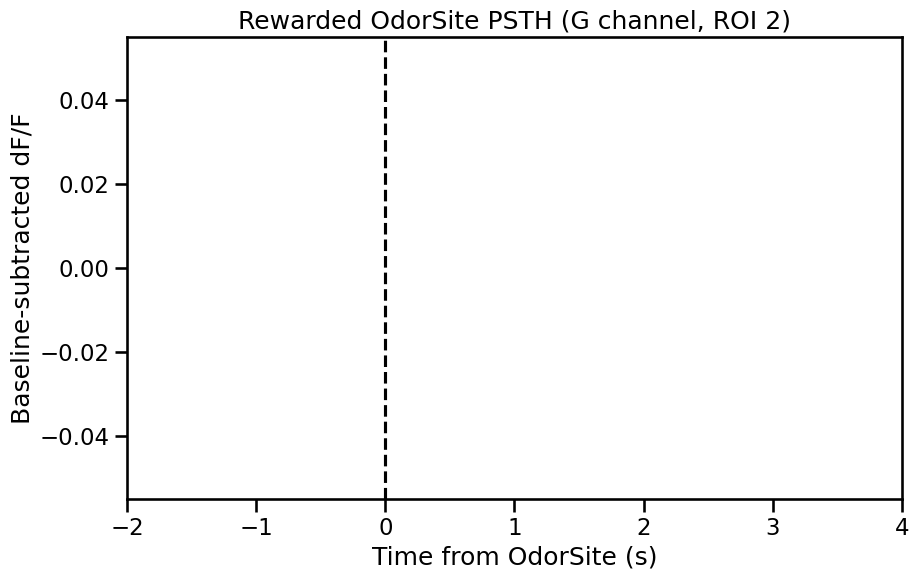

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- settings ---
CHANNEL = "G"     # or "G" / "Ctrl"
ROI = 2
BASELINE_WIN = (-2.0, 0)   # seconds relative to OdorSite
XLIM = (-2.0, 4.0)

df = aligned.copy()

# Filter to rewarded OdorSite events for one ROI/channel
od = df[
    (df["align_label"] == "OdorSite") &
    (df["label"] == "OdorSite") &
    (df["channel"] == CHANNEL) &
    (df["roi"] == ROI) &
    (df["is_choice"].astype(float) == 1.0) &
    (df["is_reward"].astype(float) == 1.0)
].copy()

# Baseline per epoch_id (pre-event window)
b0, b1 = BASELINE_WIN
base = (od[(od["t_rel"] >= b0) & (od["t_rel"] <= b1)]
        .groupby("epoch_id")["value"]
        .mean()
        .rename("baseline"))

od = od.join(base, on="epoch_id")
od = od.dropna(subset=["baseline"])
od["value_bs"] = od["value"] - od["baseline"]

# Event-weighted mean ± SEM across all rewarded odorsites
psth = (od.groupby("t_rel")["value_bs"]
        .agg(mean="mean", sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)))
        .reset_index())

# Plot
plt.figure(figsize=(10,6))
plt.plot(psth["t_rel"], psth["mean"])
plt.fill_between(psth["t_rel"], psth["mean"]-psth["sem"], psth["mean"]+psth["sem"], alpha=0.3)
plt.axvline(0, color="k", linestyle="--")
plt.xlim(*XLIM)
plt.xlabel("Time from OdorSite (s)")
plt.ylabel("Baseline-subtracted dF/F")
plt.title(f"Rewarded OdorSite PSTH ({CHANNEL} channel, ROI {ROI})")
plt.show()


In [9]:
fs = 20.0
dt = 1.0/fs
tol = dt/2 + 1e-9   # tolerance for matching patch_onset to InterSite epoch_time

In [23]:
# Focus to R channel ROI 1
aligned_R1 = aligned[(aligned["channel"] == "R") & (aligned["roi"] == 1)].copy()

# Bring epoch_time, patch_onset, and metadata onto aligned rows
# (If aligned already has mouse/session, this merge is harmless.)
meta_cols = ["epoch_id", "mouse", "session", "label", "epoch_time", "patch_onset", "reward_onset_time"]
meta_cols = [c for c in meta_cols if c in epochs.columns]  # keep only present
aligned_R1 = aligned_R1.merge(epochs[meta_cols], on="epoch_id", how="left")

# Select patch-onset InterSite epochs: align_label == "InterSite" AND epoch_time ≈ patch_onset
inter_patch_onset = aligned_R1[
    (aligned_R1["align_label"] == "InterSite") &
    (aligned_R1["patch_onset"].notna()) &
    (aligned_R1["epoch_time"].notna()) &
    (np.abs(aligned_R1["epoch_time"].astype(float) - aligned_R1["patch_onset"].astype(float)) <= tol)
].copy()

# Baseline window [-2, 0)
baseline_win = inter_patch_onset[(inter_patch_onset["t_rel"] >= -2.0) & (inter_patch_onset["t_rel"] < 0.0)].copy()

# Define a patch key. Using mouse+session+patch_onset is usually sufficient.
# pick an ID column that exists
IDCOL = "session_path" if "session_path" in epochs.columns else "session_id" if "session_id" in epochs.columns else "session"

baseline_win["patch_key"] = (
    baseline_win[IDCOL].astype(str) + "|" +
    baseline_win["patch_onset"].astype(str)
)


baseline_per_patch = (
    baseline_win.groupby("patch_key")["value"]
    .mean()
    .rename("baseline_patch")
    .reset_index()
)


In [24]:
# OdorSite-aligned rows (we re-center these)
odor = aligned_R1[
    (aligned_R1["align_label"] == "OdorSite") &
    (aligned_R1["reward_onset_time"].notna()) &
    (aligned_R1["epoch_time"].notna()) &
    (aligned_R1["patch_onset"].notna())
].copy()

odor["reward_rel"] = odor["reward_onset_time"].astype(float) - odor["epoch_time"].astype(float)
odor["t_rel_reward"] = odor["t_rel"].astype(float) - odor["reward_rel"]

# Snap to 20 Hz grid (0.05 s) so groupby works cleanly
odor["t_rel_reward_bin"] = np.round(odor["t_rel_reward"] / dt) * dt

# Optional: choose the RewardOnset PSTH window you care about
odor = odor[(odor["t_rel_reward_bin"] >= -2.0) & (odor["t_rel_reward_bin"] <= 5.0)].copy()

# Attach patch_key and baseline
odor["patch_key"] = (
    odor[IDCOL].astype(str) + "|" +
    odor["patch_onset"].astype(str)
)

odor = odor.merge(baseline_per_patch, on="patch_key", how="left")

# Baseline-subtract
odor["value_bs"] = odor["value"].astype(float) - odor["baseline_patch"].astype(float)


In [25]:
reward_psth = (
    odor.groupby("t_rel_reward_bin")["value_bs"]
    .agg(mean="mean", sem=lambda x: x.std(ddof=1) / np.sqrt(len(x)))
    .reset_index()
    .rename(columns={"t_rel_reward_bin": "t_rel_reward"})
)
reward_psth.head()


,t_rel_reward,mean,sem
0,-2.00,0.006754,0.000643
1,-1.95,0.006818,0.000644
2,-1.90,0.006915,0.000649
3,-1.85,0.006888,0.000647
4,-1.80,0.006817,0.000641


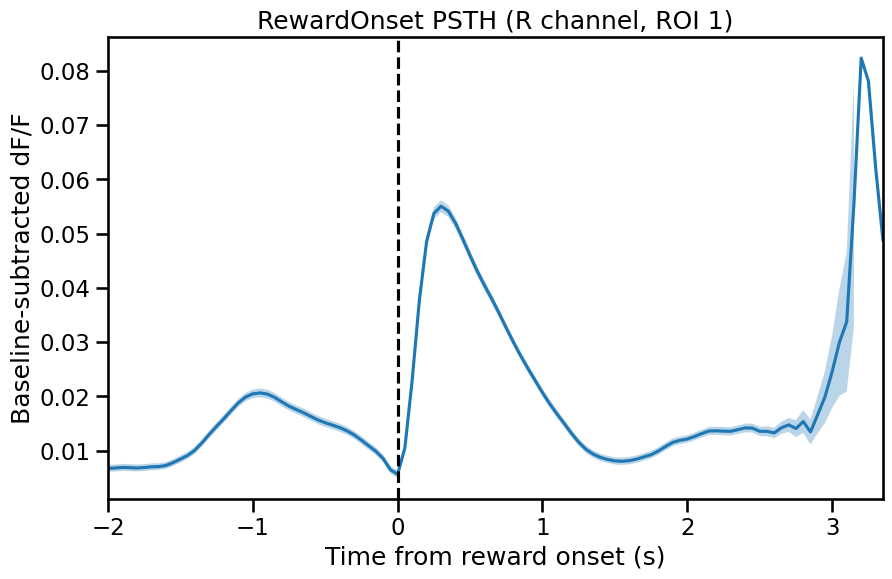

In [33]:
import matplotlib.pyplot as plt

# reward_psth should already exist from the previous steps
plt.figure(figsize=(10,6))
plt.plot(reward_psth["t_rel_reward"], reward_psth["mean"])
plt.fill_between(
    reward_psth["t_rel_reward"],
    reward_psth["mean"] - reward_psth["sem"],
    reward_psth["mean"] + reward_psth["sem"],
    alpha=0.3,
)
plt.axvline(0, color="k", linestyle="--")
plt.xlabel("Time from reward onset (s)")
plt.ylabel("Baseline-subtracted dF/F")
plt.title("RewardOnset PSTH (R channel, ROI 1)")

plt.xlim(reward_psth["t_rel_reward"].min(), reward_psth["t_rel_reward"].max())

plt.show()

## First odor site of each patch: odor value × actual reward outcome

This section tests FIP signals at entry into the **first OdorSite of each patch** for a selected ROI and channel. It provides both the pooled `odor90` versus `odor60` comparison and a 2 × 2 split by odor value and actual reward outcome:

- `odor90`, rewarded
- `odor90`, unrewarded
- `odor60`, rewarded
- `odor60`, unrewarded

**Session-wise z-scoring**

- Signals are normalized separately within each recording session.
- For each session, the baseline mean and standard deviation are calculated by pooling all selected first-site signal samples from **−4 to 0 seconds before OdorSite entry**, across odor and reward conditions.
- Every sample from that session is transformed as `(value − session baseline mean) / session baseline SD`.
- The plots and summary-window statistics are therefore reported in **z-score units**, not percent dF/F.
- A common session baseline is used for all conditions, rather than z-scoring each event independently. This removes session-to-session floor/scale differences while preserving trial-level pre-entry variation.

**Definitions and safeguards**

- The analysis explicitly uses the OdorSite-entry-aligned `ALIGNED_ALL`/`EPOCHS_ALL` tables, not the reward-onset-aligned `ALIGNED_RWD` table.
- The first site is the smallest `site_number` within each mouse × session × patch; earliest `epoch_time` is the tie-breaker and the fallback when `site_number` is unavailable.
- Odor identity is read from `odor_label` first and then `patch_label`; spellings such as `odor_90`/`odor90` and `odor_60`/`odor60` are normalized.
- Reward outcome is read from `is_reward` and normalized to `rewarded` or `unrewarded`.
- By default, the outcome split keeps only patches where the first site was **chosen/stopped** (`FIRST_ODOR_OUTCOME_REQUIRE_CHOICE = True`). This avoids treating traversed or skipped sites as unrewarded outcomes when `is_reward == 0` is used for non-choice rows. The pooled odor comparison remains independently controlled by `FIRST_ODOR_REQUIRE_CHOICE`.
- Events are averaged within session before inference. With `FIRST_ODOR_INFERENCE_UNIT = "mouse"`, session means are then averaged within mouse.
- Each paired contrast uses units containing the two cells needed for that contrast. The odor × outcome interaction requires all four cells in the same inference unit.
- The gray summary window should be kept before reward delivery when the goal is reward expectation. Reward-latency QC warns if the window overlaps early reward delivery; later portions of rewarded versus unrewarded traces can reflect reward receipt or omission rather than expectation alone.

The outcome-split output includes condition PSTHs, odor contrasts within rewarded and unrewarded trials, reward contrasts within each odor, the odor × outcome interaction, bootstrap confidence intervals, paired sign-flip tests, and Holm-adjusted p-values across the five planned summary-window contrasts.


In [227]:
# -------------------------
# First-site odor value x reward-outcome settings
# -------------------------
# IMPORTANT: these must be the OdorSite-entry-aligned tables built above
# (cell that creates ALIGNED_ALL/EPOCHS_ALL). Do not use ALIGNED_RWD here.
if "ALIGNED_ALL" not in globals() or "EPOCHS_ALL" not in globals():
    raise NameError(
        "Run the multi-session OdorSite alignment cell first, or load the "
        "aligned_all_*.csv.gz and epochs_all_*.csv.gz tables and assign them "
        "to FIRST_ODOR_ALIGNED / FIRST_ODOR_EPOCHS below."
    )

FIRST_ODOR_ALIGNED = aligned
FIRST_ODOR_EPOCHS = epochs

FIRST_ODOR_CHANNEL = "G"          # "R", "G", or "Ctrl"
FIRST_ODOR_ROI = 3                # zero-based ROI index used in the aligned table

# Session-wise z-score baseline. For each session, all first-site samples in
# this interval are pooled to estimate one baseline mean and SD.
FIRST_ODOR_BASELINE = (-2.0, 0.0)
FIRST_ODOR_NORMALIZATION = "session_zscore"

FIRST_ODOR_SUMMARY_WINDOW = (0.0, 1.0)  # verify against reward-latency QC
FIRST_ODOR_XLIM = (-2.0, 4.0)

# Controls the original pooled odor90-versus-odor60 comparison only:
# None = every patch's first site; True = first site was chosen/stopped;
# False = first site was not chosen.
FIRST_ODOR_REQUIRE_CHOICE = None

# Recommended True: reward outcome is normally interpretable only for a
# chosen/stopped site. Set False only if is_reward is meaningful for skipped sites.
FIRST_ODOR_OUTCOME_REQUIRE_CHOICE = True

# "session" is appropriate for one mouse across days. For a multi-mouse table,
# use "mouse" to average sessions within mouse before inferential summaries.
FIRST_ODOR_INFERENCE_UNIT = "session"

# Scale is only used if normalization="event_baseline". Session z-scores are
# plotted directly and should remain on a scale of 1.
FIRST_ODOR_SCALE = 1.0
FIRST_ODOR_N_BOOT = 10_000
FIRST_ODOR_N_PERM = 100_000
FIRST_ODOR_RANDOM_SEED = 12345



In [215]:
import re
import warnings
from typing import Dict, Iterable, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


_ODOR_LEVELS = ("odor90", "odor60")
_REWARD_LEVELS = ("rewarded", "unrewarded")
_OUTCOME_CONDITIONS = tuple(
    f"{odor}_{outcome}"
    for outcome in _REWARD_LEVELS
    for odor in _ODOR_LEVELS
)


def _coerce_bool_series(series: pd.Series) -> pd.Series:
    """Coerce common bool/0-1/string encodings to pandas BooleanDtype."""
    if pd.api.types.is_bool_dtype(series.dtype):
        return series.astype("boolean")

    numeric = pd.to_numeric(series, errors="coerce")
    out = pd.Series(pd.NA, index=series.index, dtype="boolean")
    out.loc[numeric.eq(1)] = True
    out.loc[numeric.eq(0)] = False

    text = series.astype("string").str.strip().str.lower()
    out.loc[text.isin(["true", "t", "yes", "y", "rewarded", "reward"])] = True
    out.loc[text.isin(["false", "f", "no", "n", "unrewarded", "omission", "omitted"])] = False
    return out


def _canonical_odor(series: pd.Series) -> pd.Series:
    """Map common spellings such as odor_90/odor90 to odor90 and odor60."""
    normalized = (
        series.astype("string")
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "", regex=True)
    )

    out = pd.Series(pd.NA, index=series.index, dtype="string")
    is_90 = normalized.str.contains("odor90", na=False) | normalized.eq("90")
    is_60 = normalized.str.contains("odor60", na=False) | normalized.eq("60")
    out.loc[is_90] = "odor90"
    out.loc[is_60] = "odor60"
    return out


def _pick_existing(columns: Iterable[str], candidates: Sequence[str]) -> Optional[str]:
    columns = set(columns)
    return next((c for c in candidates if c in columns), None)


def _filter_choice_events(
    events: pd.DataFrame,
    require_choice: Optional[bool],
    *,
    context: str,
) -> pd.DataFrame:
    """Optionally retain chosen or non-chosen first sites without redefining 'first'."""
    if require_choice is None:
        return events.copy()
    if "is_choice" not in events.columns:
        raise KeyError(f"{context} requested a choice filter, but epochs has no is_choice column")

    choice = _coerce_bool_series(events["is_choice"])
    keep = choice.eq(bool(require_choice)).fillna(False)
    filtered = events.loc[keep].copy()
    if filtered.empty:
        label = "chosen" if require_choice else "non-choice"
        raise ValueError(f"No {label} first-site events remained for {context}.")
    return filtered


def _add_reward_outcome(events: pd.DataFrame) -> Tuple[pd.DataFrame, int]:
    """Add rewarded/unrewarded labels from is_reward; return data and unknown count."""
    if "is_reward" not in events.columns:
        raise KeyError("Reward-outcome splitting requires an is_reward column in epochs.")

    out = events.copy()
    reward = _coerce_bool_series(out["is_reward"])
    out["reward_outcome"] = pd.Series(pd.NA, index=out.index, dtype="string")
    out.loc[reward.eq(True).fillna(False), "reward_outcome"] = "rewarded"
    out.loc[reward.eq(False).fillna(False), "reward_outcome"] = "unrewarded"
    unknown = int(out["reward_outcome"].isna().sum())
    out["outcome_condition"] = (
        out["odor_condition"].astype("string")
        + "_"
        + out["reward_outcome"].astype("string")
    )
    return out, unknown


def identify_first_odor_sites(
    epochs: pd.DataFrame,
    *,
    require_choice: Optional[bool] = None,
    odor_columns: Sequence[str] = ("odor_label", "patch_label"),
) -> Tuple[pd.DataFrame, Sequence[str]]:
    """
    Return exactly one first OdorSite event per patch.

    Definition:
      1. Restrict to label == 'OdorSite'.
      2. Within mouse/session/patch, choose the smallest site_number.
      3. Break ties by earliest epoch_time. If site_number is unavailable,
         choose the earliest epoch_time directly.
      4. Optionally filter the resulting first-site events by is_choice.

    Odor identity is read from odor_label first and then patch_label, with
    odor_90/odor90 and odor_60/odor60 normalized to odor90 and odor60.
    """
    required = {"epoch_id", "label"}
    missing = required.difference(epochs.columns)
    if missing:
        raise KeyError(f"epochs is missing required columns: {sorted(missing)}")

    ev = epochs.loc[epochs["label"].astype(str).eq("OdorSite")].copy()
    if ev.empty:
        raise ValueError("No rows with label == 'OdorSite' were found in epochs.")

    # Include mouse when available because session labels can repeat across animals.
    session_col = _pick_existing(ev.columns, ("session_id", "session", "session_path"))
    if session_col is None:
        raise KeyError("epochs needs one of: session_id, session, session_path")
    session_key_cols = (["mouse"] if "mouse" in ev.columns else []) + [session_col]

    patch_col = _pick_existing(ev.columns, ("patch_number", "patch_onset"))
    if patch_col is None:
        raise KeyError("epochs needs patch_number (preferred) or patch_onset")

    ev = ev.loc[ev[patch_col].notna()].copy()
    if ev.empty:
        raise ValueError(f"No OdorSite rows had a non-null {patch_col!r}.")

    patch_key_cols = list(session_key_cols) + [patch_col]
    ev["_row_order"] = np.arange(len(ev), dtype=np.int64)

    time_col = _pick_existing(ev.columns, ("epoch_time", "reward_onset_time"))
    if time_col is not None:
        ev["_time_sort"] = pd.to_numeric(ev[time_col], errors="coerce")
    else:
        ev["_time_sort"] = ev["_row_order"].astype(float)

    sort_cols = list(patch_key_cols)
    if "site_number" in ev.columns:
        ev["_site_sort"] = pd.to_numeric(ev["site_number"], errors="coerce").fillna(np.inf)
        sort_cols.append("_site_sort")
    sort_cols.extend(["_time_sort", "_row_order"])

    first = (
        ev.sort_values(sort_cols, kind="mergesort")
        .groupby(patch_key_cols, dropna=False, sort=False)
        .head(1)
        .copy()
    )

    # Choice filtering occurs after first-site identification, so True means
    # "the first site was chosen", not "the first chosen site".
    first = _filter_choice_events(
        first,
        require_choice,
        context="first-site identification",
    )

    first["odor_condition"] = pd.Series(pd.NA, index=first.index, dtype="string")
    first["odor_source_column"] = pd.Series(pd.NA, index=first.index, dtype="string")
    first["odor_source_value"] = pd.Series(pd.NA, index=first.index, dtype="string")

    for col in odor_columns:
        if col not in first.columns:
            continue
        canonical = _canonical_odor(first[col])
        fill = first["odor_condition"].isna() & canonical.notna()
        first.loc[fill, "odor_condition"] = canonical.loc[fill]
        first.loc[fill, "odor_source_column"] = col
        first.loc[fill, "odor_source_value"] = first.loc[fill, col].astype("string")

    first = first.loc[first["odor_condition"].isin(_ODOR_LEVELS)].copy()
    if first.empty:
        observed = {
            col: sorted(epochs[col].dropna().astype(str).unique().tolist())[:25]
            for col in odor_columns
            if col in epochs.columns
        }
        raise ValueError(
            "No first-site events could be labeled odor90 or odor60. "
            f"Observed candidate labels (up to 25 each): {observed}"
        )

    first = first.drop(columns=["_row_order", "_time_sort", "_site_sort"], errors="ignore")
    return first, session_key_cols


def _bootstrap_mean_ci(
    values: np.ndarray,
    *,
    n_boot: int = 10000,
    ci: float = 0.95,
    seed: int = 12345,
) -> Tuple[float, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size < 2:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    draw_idx = rng.integers(0, values.size, size=(int(n_boot), values.size))
    boot_means = values[draw_idx].mean(axis=1)
    alpha = (1.0 - ci) / 2.0
    return tuple(np.quantile(boot_means, [alpha, 1.0 - alpha]).astype(float))


def _paired_signflip_pvalue(
    differences: np.ndarray,
    *,
    n_perm: int = 100000,
    seed: int = 12345,
) -> Tuple[float, str]:
    """Two-sided paired sign-flip test of whether the mean difference is zero."""
    differences = np.asarray(differences, dtype=float)
    differences = differences[np.isfinite(differences)]
    n = differences.size
    if n < 2:
        return np.nan, "insufficient paired units"

    observed = abs(float(differences.mean()))
    eps = np.finfo(float).eps * 16

    if n <= 16:
        states = np.arange(1 << n, dtype=np.uint32)[:, None]
        bits = (states >> np.arange(n, dtype=np.uint32)) & 1
        signs = 1.0 - 2.0 * bits.astype(float)
        null = (signs * differences[None, :]).mean(axis=1)
        p = float(np.mean(np.abs(null) >= observed - eps))
        method = f"exact paired sign-flip ({1 << n:,} assignments)"
    else:
        rng = np.random.default_rng(seed)
        signs = rng.choice(np.array([-1.0, 1.0]), size=(int(n_perm), n), replace=True)
        null = (signs * differences[None, :]).mean(axis=1)
        p = float((np.count_nonzero(np.abs(null) >= observed - eps) + 1) / (len(null) + 1))
        method = f"Monte Carlo paired sign-flip ({int(n_perm):,} permutations)"

    return p, method


def _holm_adjust(pvalues: Sequence[float]) -> np.ndarray:
    """Holm family-wise-error adjustment, preserving NaNs."""
    pvalues = np.asarray(pvalues, dtype=float)
    adjusted = np.full(pvalues.shape, np.nan, dtype=float)
    valid_idx = np.flatnonzero(np.isfinite(pvalues))
    if valid_idx.size == 0:
        return adjusted

    order = valid_idx[np.argsort(pvalues[valid_idx])]
    sorted_p = pvalues[order]
    multipliers = valid_idx.size - np.arange(valid_idx.size)
    sorted_adj = np.maximum.accumulate(sorted_p * multipliers)
    sorted_adj = np.minimum(sorted_adj, 1.0)
    adjusted[order] = sorted_adj
    return adjusted


def _summarize_counts(
    events: pd.DataFrame,
    group_cols: Sequence[str],
    session_key_cols: Sequence[str],
) -> pd.DataFrame:
    event_counts = (
        events.groupby(list(group_cols), observed=True)["epoch_id"]
        .nunique()
        .rename("n_events")
        .reset_index()
    )
    session_counts = (
        events[[*group_cols, *session_key_cols]]
        .drop_duplicates()
        .groupby(list(group_cols), observed=True)
        .size()
        .rename("n_sessions")
        .reset_index()
    )
    counts = event_counts.merge(session_counts, on=list(group_cols), how="outer")

    if "mouse" in events.columns:
        mouse_counts = (
            events[[*group_cols, "mouse"]]
            .drop_duplicates()
            .groupby(list(group_cols), observed=True)
            .size()
            .rename("n_mice")
            .reset_index()
        )
        counts = counts.merge(mouse_counts, on=list(group_cols), how="left")
    else:
        counts["n_mice"] = np.nan
    return counts


def _reward_split_contrast_specs():
    return [
        {
            "contrast": "odor90_minus_odor60_rewarded",
            "contrast_label": "odor90 - odor60 | rewarded",
            "coefficients": {"odor90_rewarded": 1.0, "odor60_rewarded": -1.0},
        },
        {
            "contrast": "odor90_minus_odor60_unrewarded",
            "contrast_label": "odor90 - odor60 | unrewarded",
            "coefficients": {"odor90_unrewarded": 1.0, "odor60_unrewarded": -1.0},
        },
        {
            "contrast": "rewarded_minus_unrewarded_odor90",
            "contrast_label": "rewarded - unrewarded | odor90",
            "coefficients": {"odor90_rewarded": 1.0, "odor90_unrewarded": -1.0},
        },
        {
            "contrast": "rewarded_minus_unrewarded_odor60",
            "contrast_label": "rewarded - unrewarded | odor60",
            "coefficients": {"odor60_rewarded": 1.0, "odor60_unrewarded": -1.0},
        },
        {
            "contrast": "odor_by_reward_interaction",
            "contrast_label": "odor x outcome interaction",
            "coefficients": {
                "odor90_rewarded": 1.0,
                "odor60_rewarded": -1.0,
                "odor90_unrewarded": -1.0,
                "odor60_unrewarded": 1.0,
            },
        },
    ]


def _compute_reward_split_timecourse_contrasts(
    unit_psth: pd.DataFrame,
    unit_cols: Sequence[str],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    index_cols = [*unit_cols, "t_rel"]
    wide = unit_psth.pivot_table(
        index=index_cols,
        columns="outcome_condition",
        values="value_plot",
        aggfunc="mean",
    ).reset_index()

    by_unit_parts = []
    for spec in _reward_split_contrast_specs():
        required = list(spec["coefficients"])
        if not set(required).issubset(wide.columns):
            continue
        part = wide.dropna(subset=required).copy()
        if part.empty:
            continue
        part["difference"] = 0.0
        for col, coefficient in spec["coefficients"].items():
            part["difference"] += coefficient * part[col]
        part["contrast"] = spec["contrast"]
        part["contrast_label"] = spec["contrast_label"]
        by_unit_parts.append(
            part[[*index_cols, "contrast", "contrast_label", "difference"]]
        )

    if by_unit_parts:
        by_unit = pd.concat(by_unit_parts, ignore_index=True)
        stats = (
            by_unit.groupby(["contrast", "contrast_label", "t_rel"], as_index=False)["difference"]
            .agg(mean="mean", std="std", n_units="count")
        )
        stats["sem"] = stats["std"] / np.sqrt(stats["n_units"])
    else:
        by_unit = pd.DataFrame(
            columns=[*index_cols, "contrast", "contrast_label", "difference"]
        )
        stats = pd.DataFrame(
            columns=["contrast", "contrast_label", "t_rel", "mean", "std", "n_units", "sem"]
        )
    return by_unit, stats


def _compute_reward_split_window_contrasts(
    unit_window_long: pd.DataFrame,
    unit_cols: Sequence[str],
    *,
    n_boot: int,
    n_perm: int,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    wide = unit_window_long.pivot_table(
        index=list(unit_cols),
        columns="outcome_condition",
        values="window_mean",
        aggfunc="mean",
    ).reset_index()

    by_unit_parts = []
    summary_rows = []
    for i, spec in enumerate(_reward_split_contrast_specs()):
        required = list(spec["coefficients"])
        if set(required).issubset(wide.columns):
            part = wide.dropna(subset=required).copy()
        else:
            part = wide.iloc[0:0].copy()

        if not part.empty:
            part["difference"] = 0.0
            for col, coefficient in spec["coefficients"].items():
                part["difference"] += coefficient * part[col]
            compact = part[[*unit_cols, "difference"]].copy()
            compact["contrast"] = spec["contrast"]
            compact["contrast_label"] = spec["contrast_label"]
            by_unit_parts.append(compact)
            differences = part["difference"].to_numpy(float)
        else:
            differences = np.array([], dtype=float)

        mean_diff = float(np.nanmean(differences)) if differences.size else np.nan
        ci_low, ci_high = _bootstrap_mean_ci(
            differences,
            n_boot=n_boot,
            seed=seed + i,
        )
        p_value, test_method = _paired_signflip_pvalue(
            differences,
            n_perm=n_perm,
            seed=seed + i,
        )
        sd_diff = float(np.nanstd(differences, ddof=1)) if differences.size >= 2 else np.nan
        cohen_dz = mean_diff / sd_diff if np.isfinite(sd_diff) and sd_diff > 0 else np.nan

        summary_rows.append(
            {
                "contrast": spec["contrast"],
                "contrast_label": spec["contrast_label"],
                "n_paired_units": int(np.isfinite(differences).sum()),
                "mean_difference": mean_diff,
                "bootstrap_95ci_low": ci_low,
                "bootstrap_95ci_high": ci_high,
                "cohen_dz": cohen_dz,
                "paired_signflip_p": p_value,
                "test_method": test_method,
            }
        )

    by_unit = (
        pd.concat(by_unit_parts, ignore_index=True)
        if by_unit_parts
        else pd.DataFrame(columns=[*unit_cols, "difference", "contrast", "contrast_label"])
    )
    summary = pd.DataFrame(summary_rows)
    summary["holm_adjusted_p"] = _holm_adjust(summary["paired_signflip_p"].to_numpy(float))
    return wide, by_unit, summary


def analyze_first_odor_value_signal(
    aligned: pd.DataFrame,
    epochs: pd.DataFrame,
    *,
    channel: str = "R",
    roi: int = 1,
    baseline_window: Tuple[float, float] = (-4.0, 0.0),
    summary_window: Tuple[float, float] = (0.0, 1.0),
    xlim: Tuple[float, float] = (-4.0, 4.0),
    require_choice: Optional[bool] = None,
    outcome_require_choice: bool = True,
    inference_unit: str = "session",
    source_column: str = "value",
    normalization: str = "session_zscore",
    scale: float = 1.0,
    n_boot: int = 10000,
    n_perm: int = 100000,
    seed: int = 12345,
) -> Dict[str, object]:
    """
    Analyze first-patch-site FIP responses by odor and actual reward outcome.

    Two related analyses are returned:
      1. The original pooled odor90-versus-odor60 comparison. require_choice
         controls which first sites enter this pooled comparison.
      2. A 2 x 2 odor (odor90/odor60) by outcome (rewarded/unrewarded) split.
         By default, outcome_require_choice=True limits this split to patches
         where the first site was chosen/stopped, preventing skipped sites from
         being mislabeled as unrewarded outcomes.

    By default, signals are z-scored separately within each session. One
    baseline mean and population SD are estimated by pooling all selected
    first-site samples in baseline_window across odor and outcome conditions.
    The same session baseline is then applied to every event in that session.

    Events are averaged within session first. For inference_unit='mouse', the
    session means are then averaged within mouse. Pairwise contrasts use only
    units containing the cells required for that contrast; the interaction uses
    units containing all four cells.
    """
    normalization = str(normalization).strip().lower()
    normalization_aliases = {
        "session_z": "session_zscore",
        "zscore": "session_zscore",
        "session-zscore": "session_zscore",
        "event_bs": "event_baseline",
        "baseline_subtract": "event_baseline",
    }
    normalization = normalization_aliases.get(normalization, normalization)
    if normalization not in {"session_zscore", "event_baseline"}:
        raise ValueError(
            "normalization must be 'session_zscore' or 'event_baseline'"
        )
    if inference_unit not in {"session", "mouse"}:
        raise ValueError("inference_unit must be 'session' or 'mouse'")
    if baseline_window[0] >= baseline_window[1]:
        raise ValueError("baseline_window must be (start, end) with start < end")
    if summary_window[0] >= summary_window[1]:
        raise ValueError("summary_window must be (start, end) with start < end")

    required_aligned = {"epoch_id", "align_label", "channel", "roi", "t_rel", source_column}
    missing = required_aligned.difference(aligned.columns)
    if missing:
        raise KeyError(f"aligned is missing required columns: {sorted(missing)}")

    # Identify the first site once without a choice filter. The pooled and
    # outcome-split analyses can then apply different, explicit filters.
    all_first_events, session_key_cols = identify_first_odor_sites(
        epochs,
        require_choice=None,
    )
    all_first_events, n_unknown_reward_all = _add_reward_outcome(all_first_events)

    first_events = _filter_choice_events(
        all_first_events,
        require_choice,
        context="the pooled odor comparison",
    )

    if outcome_require_choice:
        outcome_candidates = _filter_choice_events(
            all_first_events,
            True,
            context="the reward-outcome split",
        )
    else:
        outcome_candidates = all_first_events.copy()
        warnings.warn(
            "The reward-outcome split includes non-choice first sites. Verify that "
            "is_reward is meaningful for traversed/skipped sites in this task.",
            RuntimeWarning,
        )

    n_outcome_candidates = int(len(outcome_candidates))
    n_unknown_outcome = int(outcome_candidates["reward_outcome"].isna().sum())
    outcome_events = outcome_candidates.dropna(subset=["reward_outcome"]).copy()
    outcome_events = outcome_events.loc[
        outcome_events["outcome_condition"].isin(_OUTCOME_CONDITIONS)
    ].copy()
    if outcome_events.empty:
        raise ValueError(
            "No first-site events had a usable rewarded/unrewarded label after "
            "the outcome choice filter. Check is_choice and is_reward encodings."
        )
    if n_unknown_outcome:
        warnings.warn(
            f"Dropped {n_unknown_outcome} outcome-candidate first-site events with "
            "an unrecognized or missing is_reward value.",
            RuntimeWarning,
        )

    # Pull all first-site traces once; subsets are formed after baseline QC.
    event_ids = all_first_events["epoch_id"].dropna()
    channel_key = str(channel).strip().upper()
    channel_value = {"C": "Ctrl", "CTRL": "Ctrl", "G": "G", "R": "R"}.get(
        channel_key,
        channel,
    )

    mask = (
        aligned["align_label"].eq("OdorSite")
        & aligned["channel"].eq(channel_value)
        & aligned["roi"].eq(int(roi))
        & aligned["epoch_id"].isin(event_ids)
    )

    keep_cols = ["epoch_id", "t_rel", source_column]
    all_traces = aligned.loc[mask, keep_cols].copy()
    if all_traces.empty:
        available_channels = sorted(aligned["channel"].dropna().astype(str).unique().tolist())
        available_rois = sorted(
            pd.to_numeric(aligned["roi"], errors="coerce").dropna().unique().tolist()
        )
        raise ValueError(
            "No aligned samples matched the selected first-site events, channel, and ROI. "
            f"Requested channel={channel!r}, roi={roi}; "
            f"available channels={available_channels}, available rois={available_rois}. "
            "Use the odor-site-aligned ALIGNED_ALL table, not ALIGNED_RWD."
        )

    # Harmonize epoch_id after subsetting; this protects merges after CSV round-trips.
    all_traces["epoch_id"] = all_traces["epoch_id"].astype(str)
    all_first_events = all_first_events.copy()
    first_events = first_events.copy()
    outcome_events = outcome_events.copy()
    for frame in (all_first_events, first_events, outcome_events):
        frame["epoch_id"] = frame["epoch_id"].astype(str)

    meta_cols = [
        "epoch_id",
        "odor_condition",
        "odor_source_column",
        "odor_source_value",
        "reward_outcome",
        "outcome_condition",
        *session_key_cols,
    ]
    for col in (
        "patch_number",
        "patch_onset",
        "site_number",
        "epoch_time",
        "reward_onset_time",
        "is_choice",
        "is_reward",
    ):
        if col in all_first_events.columns and col not in meta_cols:
            meta_cols.append(col)

    all_traces = all_traces.merge(
        all_first_events[meta_cols].drop_duplicates("epoch_id"),
        on="epoch_id",
        how="inner",
        validate="many_to_one",
    )
    all_traces["t_rel"] = pd.to_numeric(all_traces["t_rel"], errors="coerce")
    all_traces[source_column] = pd.to_numeric(all_traces[source_column], errors="coerce")
    all_traces = all_traces.dropna(subset=["t_rel", source_column]).copy()

    b0, b1 = baseline_window
    baseline_mask = all_traces["t_rel"].ge(b0) & all_traces["t_rel"].lt(b1)
    n_events_before_baseline = all_traces["epoch_id"].nunique()

    if normalization == "session_zscore":
        # Estimate one common baseline distribution per session using all
        # selected first-site samples. Odor and outcome conditions are pooled
        # so condition labels cannot change the normalization denominator.
        session_baseline_stats = (
            all_traces.loc[baseline_mask]
            .groupby(session_key_cols, dropna=False, sort=False)
            .agg(
                session_baseline_mean=(source_column, "mean"),
                session_baseline_sd=(
                    source_column,
                    lambda x: float(np.nanstd(np.asarray(x, dtype=float), ddof=0)),
                ),
                n_baseline_samples=(source_column, "count"),
                n_baseline_events=("epoch_id", "nunique"),
            )
            .reset_index()
        )
        session_baseline_stats["valid_baseline"] = (
            session_baseline_stats["n_baseline_samples"].ge(2)
            & np.isfinite(session_baseline_stats["session_baseline_mean"])
            & np.isfinite(session_baseline_stats["session_baseline_sd"])
            & session_baseline_stats["session_baseline_sd"].gt(0)
        )

        n_sessions_total = int(
            all_traces[session_key_cols].drop_duplicates().shape[0]
        )
        valid_session_baselines = session_baseline_stats.loc[
            session_baseline_stats["valid_baseline"]
        ].copy()
        n_sessions_valid = int(len(valid_session_baselines))
        if n_sessions_valid == 0:
            raise ValueError(
                "No session had at least two finite baseline samples with a "
                f"non-zero SD in baseline_window={baseline_window}."
            )
        if n_sessions_valid < n_sessions_total:
            warnings.warn(
                f"Dropped {n_sessions_total - n_sessions_valid} session(s) without "
                "a valid non-zero baseline SD.",
                RuntimeWarning,
            )

        all_traces = all_traces.merge(
            valid_session_baselines[
                [
                    *session_key_cols,
                    "session_baseline_mean",
                    "session_baseline_sd",
                    "n_baseline_samples",
                    "n_baseline_events",
                ]
            ],
            on=session_key_cols,
            how="inner",
            validate="many_to_one",
        )
        all_traces["value_z"] = (
            all_traces[source_column] - all_traces["session_baseline_mean"]
        ) / all_traces["session_baseline_sd"]
        all_traces["value_plot"] = all_traces["value_z"]
        normalization_label = "session baseline z-score"
        signal_ylabel = "Session df/F (z-score)"
        difference_unit = "z-score"
        summary_unit = "z-score"
    else:
        # Retained as an optional compatibility mode. This reproduces the
        # original per-event baseline subtraction and optional scaling.
        baseline = (
            all_traces.loc[baseline_mask]
            .groupby("epoch_id", sort=False)[source_column]
            .mean()
            .rename("event_baseline")
        )
        all_traces = all_traces.join(baseline, on="epoch_id")
        all_traces = all_traces.dropna(subset=["event_baseline"]).copy()
        if all_traces.empty:
            raise ValueError(
                f"No first-site event had valid data in baseline_window={baseline_window}."
            )
        all_traces["value_bs"] = (
            all_traces[source_column] - all_traces["event_baseline"]
        )
        all_traces["value_plot"] = all_traces["value_bs"] * float(scale)
        session_baseline_stats = pd.DataFrame()
        normalization_label = "per-event baseline subtraction"
        signal_ylabel = "Baseline-subtracted dF/F (%)"
        difference_unit = "% dF/F"
        summary_unit = "% dF/F"

    n_events_after_baseline = all_traces["epoch_id"].nunique()
    if n_events_after_baseline == 0:
        raise ValueError(
            f"No first-site event survived baseline QC for {baseline_window}."
        )
    if n_events_after_baseline < n_events_before_baseline:
        warnings.warn(
            f"Dropped {n_events_before_baseline - n_events_after_baseline} first-site events "
            "because their session/event baseline was invalid.",
            RuntimeWarning,
        )

    valid_ids = set(all_traces["epoch_id"].unique())

    # -------------------------
    # Original pooled odor comparison
    # -------------------------
    first_valid = first_events.loc[first_events["epoch_id"].isin(valid_ids)].copy()
    traces = all_traces.loc[all_traces["epoch_id"].isin(first_valid["epoch_id"])].copy()
    if traces.empty:
        raise ValueError("No pooled-comparison first-site event survived baseline QC.")

    counts = _summarize_counts(first_valid, ["odor_condition"], session_key_cols)

    session_psth = (
        traces.groupby(
            [*session_key_cols, "odor_condition", "t_rel"],
            as_index=False,
            observed=True,
        )["value_plot"]
        .mean()
    )

    coverage = (
        session_psth[[*session_key_cols, "odor_condition"]]
        .drop_duplicates()
        .groupby(session_key_cols, dropna=False)["odor_condition"]
        .nunique()
        .rename("n_odors")
        .reset_index()
    )
    paired_session_keys = coverage.loc[coverage["n_odors"].ge(2), session_key_cols]
    paired_session_psth = session_psth.merge(
        paired_session_keys,
        on=session_key_cols,
        how="inner",
        validate="many_to_many",
    )
    if paired_session_psth.empty:
        raise ValueError("No session contained both odor90 and odor60 first-site events after QC.")

    if inference_unit == "mouse":
        if "mouse" not in paired_session_psth.columns:
            raise KeyError("inference_unit='mouse' requires a mouse column")
        unit_cols = ["mouse"]
        unit_psth = (
            paired_session_psth.groupby(
                ["mouse", "odor_condition", "t_rel"],
                as_index=False,
                observed=True,
            )["value_plot"]
            .mean()
        )
    else:
        unit_cols = list(session_key_cols)
        unit_psth = paired_session_psth.copy()

    psth_stats = (
        unit_psth.groupby(["odor_condition", "t_rel"], as_index=False, observed=True)["value_plot"]
        .agg(mean="mean", std="std", n_units="count")
    )
    psth_stats["sem"] = psth_stats["std"] / np.sqrt(psth_stats["n_units"])

    diff_wide = unit_psth.pivot_table(
        index=[*unit_cols, "t_rel"],
        columns="odor_condition",
        values="value_plot",
        aggfunc="mean",
    ).reset_index()
    if not set(_ODOR_LEVELS).issubset(diff_wide.columns):
        raise ValueError("Could not form paired odor90/odor60 PSTHs.")
    diff_wide = diff_wide.dropna(subset=list(_ODOR_LEVELS)).copy()
    diff_wide["difference"] = diff_wide["odor90"] - diff_wide["odor60"]

    diff_stats = (
        diff_wide.groupby("t_rel", as_index=False)["difference"]
        .agg(mean="mean", std="std", n_units="count")
    )
    diff_stats["sem"] = diff_stats["std"] / np.sqrt(diff_stats["n_units"])

    w0, w1 = summary_window
    window_mask = traces["t_rel"].ge(w0) & traces["t_rel"].lt(w1)
    event_window = (
        traces.loc[window_mask]
        .groupby(
            ["epoch_id", *session_key_cols, "odor_condition"],
            as_index=False,
            observed=True,
        )["value_plot"]
        .mean()
        .rename(columns={"value_plot": "window_mean"})
    )
    if event_window.empty:
        raise ValueError(
            f"No samples fell inside summary_window={summary_window}. "
            "Choose a window within the aligned t_rel range."
        )

    session_window = (
        event_window.groupby(
            [*session_key_cols, "odor_condition"],
            as_index=False,
            observed=True,
        )["window_mean"]
        .mean()
    )
    paired_session_window = session_window.merge(
        paired_session_keys,
        on=session_key_cols,
        how="inner",
        validate="many_to_many",
    )

    if inference_unit == "mouse":
        unit_window_long = (
            paired_session_window.groupby(
                ["mouse", "odor_condition"],
                as_index=False,
                observed=True,
            )["window_mean"]
            .mean()
        )
    else:
        unit_window_long = paired_session_window.copy()

    unit_window = unit_window_long.pivot_table(
        index=unit_cols,
        columns="odor_condition",
        values="window_mean",
        aggfunc="mean",
    ).reset_index()
    unit_window = unit_window.dropna(subset=list(_ODOR_LEVELS)).copy()
    unit_window["difference_odor90_minus_odor60"] = (
        unit_window["odor90"] - unit_window["odor60"]
    )

    differences = unit_window["difference_odor90_minus_odor60"].to_numpy(float)
    mean_diff = float(np.nanmean(differences)) if differences.size else np.nan
    ci_low, ci_high = _bootstrap_mean_ci(differences, n_boot=n_boot, seed=seed)
    p_value, test_method = _paired_signflip_pvalue(
        differences,
        n_perm=n_perm,
        seed=seed,
    )
    sd_diff = float(np.nanstd(differences, ddof=1)) if differences.size >= 2 else np.nan
    cohen_dz = mean_diff / sd_diff if np.isfinite(sd_diff) and sd_diff > 0 else np.nan

    summary_stats = pd.DataFrame(
        [
            {
                "channel": str(channel),
                "roi": int(roi),
                "inference_unit": inference_unit,
                "normalization": normalization,
                "n_paired_units": int(len(unit_window)),
                "summary_window_start_s": float(w0),
                "summary_window_end_s": float(w1),
                "mean_odor90_minus_odor60": mean_diff,
                "bootstrap_95ci_low": ci_low,
                "bootstrap_95ci_high": ci_high,
                "cohen_dz": cohen_dz,
                "paired_signflip_p": p_value,
                "test_method": test_method,
            }
        ]
    )

    # -------------------------
    # Odor x actual reward-outcome split
    # -------------------------
    outcome_first_valid = outcome_events.loc[
        outcome_events["epoch_id"].isin(valid_ids)
    ].copy()
    outcome_traces = all_traces.loc[
        all_traces["epoch_id"].isin(outcome_first_valid["epoch_id"])
        & all_traces["reward_outcome"].isin(_REWARD_LEVELS)
    ].copy()
    if outcome_traces.empty:
        raise ValueError("No reward-outcome first-site event survived baseline QC.")

    outcome_counts = _summarize_counts(
        outcome_first_valid,
        ["odor_condition", "reward_outcome"],
        session_key_cols,
    )

    outcome_session_psth = (
        outcome_traces.groupby(
            [
                *session_key_cols,
                "odor_condition",
                "reward_outcome",
                "outcome_condition",
                "t_rel",
            ],
            as_index=False,
            observed=True,
        )["value_plot"]
        .mean()
    )

    if inference_unit == "mouse":
        if "mouse" not in outcome_session_psth.columns:
            raise KeyError("inference_unit='mouse' requires a mouse column")
        outcome_unit_cols = ["mouse"]
        outcome_unit_psth = (
            outcome_session_psth.groupby(
                [
                    "mouse",
                    "odor_condition",
                    "reward_outcome",
                    "outcome_condition",
                    "t_rel",
                ],
                as_index=False,
                observed=True,
            )["value_plot"]
            .mean()
        )
    else:
        outcome_unit_cols = list(session_key_cols)
        outcome_unit_psth = outcome_session_psth.copy()

    outcome_psth_stats = (
        outcome_unit_psth.groupby(
            ["odor_condition", "reward_outcome", "outcome_condition", "t_rel"],
            as_index=False,
            observed=True,
        )["value_plot"]
        .agg(mean="mean", std="std", n_units="count")
    )
    outcome_psth_stats["sem"] = (
        outcome_psth_stats["std"] / np.sqrt(outcome_psth_stats["n_units"])
    )

    outcome_contrast_by_unit, outcome_contrast_stats = (
        _compute_reward_split_timecourse_contrasts(
            outcome_unit_psth,
            outcome_unit_cols,
        )
    )

    outcome_window_mask = (
        outcome_traces["t_rel"].ge(w0) & outcome_traces["t_rel"].lt(w1)
    )
    outcome_event_window = (
        outcome_traces.loc[outcome_window_mask]
        .groupby(
            [
                "epoch_id",
                *session_key_cols,
                "odor_condition",
                "reward_outcome",
                "outcome_condition",
            ],
            as_index=False,
            observed=True,
        )["value_plot"]
        .mean()
        .rename(columns={"value_plot": "window_mean"})
    )
    if outcome_event_window.empty:
        raise ValueError(
            f"No reward-split samples fell inside summary_window={summary_window}."
        )

    outcome_session_window = (
        outcome_event_window.groupby(
            [
                *session_key_cols,
                "odor_condition",
                "reward_outcome",
                "outcome_condition",
            ],
            as_index=False,
            observed=True,
        )["window_mean"]
        .mean()
    )

    if inference_unit == "mouse":
        outcome_unit_window_long = (
            outcome_session_window.groupby(
                ["mouse", "odor_condition", "reward_outcome", "outcome_condition"],
                as_index=False,
                observed=True,
            )["window_mean"]
            .mean()
        )
    else:
        outcome_unit_window_long = outcome_session_window.copy()

    (
        outcome_unit_window_wide,
        outcome_window_contrast_by_unit,
        outcome_contrast_summary,
    ) = _compute_reward_split_window_contrasts(
        outcome_unit_window_long,
        outcome_unit_cols,
        n_boot=n_boot,
        n_perm=n_perm,
        seed=seed + 1000,
    )
    outcome_contrast_summary.insert(0, "channel", str(channel))
    outcome_contrast_summary.insert(1, "roi", int(roi))
    outcome_contrast_summary.insert(2, "inference_unit", inference_unit)
    outcome_contrast_summary.insert(3, "normalization", normalization)
    outcome_contrast_summary.insert(4, "summary_window_start_s", float(w0))
    outcome_contrast_summary.insert(5, "summary_window_end_s", float(w1))

    outcome_qc = pd.DataFrame(
        [
            {
                "n_first_sites_with_odor_label": int(len(all_first_events)),
                "outcome_require_choice": bool(outcome_require_choice),
                "n_outcome_candidates_before_reward_label_qc": n_outcome_candidates,
                "n_unknown_is_reward_dropped": n_unknown_outcome,
                "n_outcome_events_after_reward_label_qc": int(len(outcome_events)),
                "n_outcome_events_after_baseline_qc": int(len(outcome_first_valid)),
                "n_unknown_is_reward_all_first_sites": n_unknown_reward_all,
            }
        ]
    )

    # Reward-latency QC: expectation windows should ideally end before delivery.
    latency_summary = pd.DataFrame()
    reward_latency_quantiles = None
    if {"reward_onset_time", "epoch_time"}.issubset(outcome_first_valid.columns):
        latency = outcome_first_valid.loc[
            outcome_first_valid["reward_outcome"].eq("rewarded"),
            [
                "epoch_id",
                "odor_condition",
                "reward_outcome",
                "reward_onset_time",
                "epoch_time",
            ],
        ].copy()
        latency["reward_latency_s"] = (
            pd.to_numeric(latency["reward_onset_time"], errors="coerce")
            - pd.to_numeric(latency["epoch_time"], errors="coerce")
        )
        latency = latency.loc[
            np.isfinite(latency["reward_latency_s"])
            & latency["reward_latency_s"].gt(0)
        ].copy()
        if not latency.empty:
            latency_summary = (
                latency.groupby(
                    ["odor_condition", "reward_outcome"],
                    observed=True,
                )["reward_latency_s"]
                .agg(
                    n_rewarded="count",
                    min="min",
                    q05=lambda x: x.quantile(0.05),
                    median="median",
                )
                .reset_index()
            )
            reward_latency_quantiles = latency["reward_latency_s"].quantile([0.05, 0.5]).to_dict()
            q05 = float(reward_latency_quantiles.get(0.05, np.nan))
            if np.isfinite(q05) and w1 > q05:
                warnings.warn(
                    f"summary_window ends at {w1:.3g} s, after the 5th percentile "
                    f"rewarded-site reward latency ({q05:.3g} s). Shorten the window "
                    "to isolate expectation from reward delivery.",
                    RuntimeWarning,
                )

    return {
        "settings": {
            "channel": str(channel),
            "roi": int(roi),
            "baseline_window": tuple(baseline_window),
            "summary_window": tuple(summary_window),
            "xlim": tuple(xlim),
            "require_choice": require_choice,
            "outcome_require_choice": bool(outcome_require_choice),
            "inference_unit": inference_unit,
            "source_column": source_column,
            "normalization": normalization,
            "normalization_label": normalization_label,
            "signal_ylabel": signal_ylabel,
            "difference_unit": difference_unit,
            "summary_unit": summary_unit,
            "scale": float(scale),
        },
        "all_first_events": all_first_events.loc[
            all_first_events["epoch_id"].isin(valid_ids)
        ].copy(),
        "all_traces": all_traces,
        "session_baseline_stats": session_baseline_stats,
        # Original pooled odor comparison keys
        "first_events": first_valid,
        "traces": traces,
        "counts": counts,
        "session_psth": session_psth,
        "paired_session_psth": paired_session_psth,
        "unit_psth": unit_psth,
        "psth_stats": psth_stats,
        "difference_by_unit": diff_wide,
        "difference_stats": diff_stats,
        "event_window": event_window,
        "session_window": session_window,
        "unit_window": unit_window,
        "summary_stats": summary_stats,
        # Reward-outcome split keys
        "outcome_qc": outcome_qc,
        "outcome_first_events": outcome_first_valid,
        "outcome_traces": outcome_traces,
        "outcome_counts": outcome_counts,
        "outcome_session_psth": outcome_session_psth,
        "outcome_unit_psth": outcome_unit_psth,
        "outcome_psth_stats": outcome_psth_stats,
        "outcome_contrast_by_unit": outcome_contrast_by_unit,
        "outcome_contrast_stats": outcome_contrast_stats,
        "outcome_event_window": outcome_event_window,
        "outcome_session_window": outcome_session_window,
        "outcome_unit_window_long": outcome_unit_window_long,
        "outcome_unit_window_wide": outcome_unit_window_wide,
        "outcome_window_contrast_by_unit": outcome_window_contrast_by_unit,
        "outcome_contrast_summary": outcome_contrast_summary,
        # Reward timing QC
        "reward_latency_summary": latency_summary,
        "reward_latency_quantiles": reward_latency_quantiles,
    }

def plot_first_odor_value_signal(
    result: Dict[str, object],
    *,
    figsize: Tuple[float, float] = (17.0, 5.2),
    colors: Optional[Dict[str, str]] = None,
):
    """Plot the original pooled odor comparison, retained for continuity."""
    if colors is None:
        colors = {"odor90": "#d95f02", "odor60": "#1b9e77"}

    settings = result["settings"]
    signal_ylabel = settings.get("signal_ylabel", "Baseline-subtracted dF/F (%)")
    difference_unit = settings.get("difference_unit", "% dF/F")
    summary_unit = settings.get("summary_unit", "% dF/F")
    psth_stats = result["psth_stats"]
    diff_stats = result["difference_stats"]
    unit_window = result["unit_window"]
    summary_stats = result["summary_stats"].iloc[0]
    counts = result["counts"].set_index("odor_condition").to_dict("index")

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    ax_trace, ax_diff, ax_pair = axes

    label_names = {"odor90": "odor90 (high value)", "odor60": "odor60 (lower value)"}
    for odor in _ODOR_LEVELS:
        s = psth_stats.loc[psth_stats["odor_condition"].eq(odor)].sort_values("t_rel")
        if s.empty:
            continue
        t = s["t_rel"].to_numpy(float)
        mean = s["mean"].to_numpy(float)
        sem = s["sem"].to_numpy(float)
        n_events = int(counts.get(odor, {}).get("n_events", 0))
        n_units = int(np.nanmax(s["n_units"].to_numpy(float)))
        ax_trace.plot(
            t,
            mean,
            linewidth=2.2,
            color=colors[odor],
            label=f"{label_names[odor]} ({n_events} patches, {n_units} sessions)",
        )
        ax_trace.fill_between(
            t,
            mean - sem,
            mean + sem,
            color=colors[odor],
            alpha=0.20,
            linewidth=0,
        )

    w0, w1 = settings["summary_window"]
    for ax in (ax_trace, ax_diff):
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.axhline(0, color="black", linestyle=":", linewidth=0.8, alpha=0.7)
        ax.axvspan(w0, w1, color="0.5", alpha=0.10, linewidth=0)
        ax.set_xlim(*settings["xlim"])
        ax.set_xlabel("Time from first OdorSite entry (s)")

    ax_trace.set_ylabel(signal_ylabel)
    ax_trace.set_title(
        f"First site: pooled odor comparison\n{settings['channel']} channel, ROI {settings['roi']}; "
        f"{settings['normalization_label']}"
    )
    ax_trace.legend(frameon=False, fontsize=9)

    d = diff_stats.sort_values("t_rel")
    t = d["t_rel"].to_numpy(float)
    mean = d["mean"].to_numpy(float)
    sem = d["sem"].to_numpy(float)
    ax_diff.plot(t, mean, linewidth=2.2, color="black")
    ax_diff.fill_between(t, mean - sem, mean + sem, color="black", alpha=0.18, linewidth=0)
    ax_diff.set_ylabel(f"odor90 - odor60 ({difference_unit})")
    ax_diff.set_title("Within-unit pooled odor difference")

    x = np.array([0.0, 1.0])
    for _, row in unit_window.iterrows():
        ax_pair.plot(
            x,
            [row["odor60"], row["odor90"]],
            color="0.65",
            linewidth=1,
            alpha=0.75,
            zorder=1,
        )
        ax_pair.scatter(
            x,
            [row["odor60"], row["odor90"]],
            color=[colors["odor60"], colors["odor90"]],
            s=32,
            zorder=2,
        )

    means = [unit_window["odor60"].mean(), unit_window["odor90"].mean()]
    sems = [
        unit_window["odor60"].std(ddof=1) / np.sqrt(len(unit_window))
        if len(unit_window) > 1
        else np.nan,
        unit_window["odor90"].std(ddof=1) / np.sqrt(len(unit_window))
        if len(unit_window) > 1
        else np.nan,
    ]
    ax_pair.errorbar(
        x,
        means,
        yerr=sems,
        fmt="o",
        color="black",
        markersize=7,
        capsize=4,
        linewidth=1.5,
        zorder=3,
    )
    ax_pair.set_xticks(x, ["odor60\n(lower)", "odor90\n(high)"])
    ax_pair.set_ylabel(f"Mean {summary_unit}, {w0:g} to {w1:g} s")
    ax_pair.axhline(0, color="black", linestyle=":", linewidth=0.8, alpha=0.7)
    ax_pair.set_title(f"Paired {settings['inference_unit']} summary")

    mean_diff = summary_stats["mean_odor90_minus_odor60"]
    ci_low = summary_stats["bootstrap_95ci_low"]
    ci_high = summary_stats["bootstrap_95ci_high"]
    p_value = summary_stats["paired_signflip_p"]
    n_units = int(summary_stats["n_paired_units"])
    annotation = (
        f"odor90 - odor60 = {mean_diff:.3g}\n"
        f"95% bootstrap CI [{ci_low:.3g}, {ci_high:.3g}]\n"
        f"paired sign-flip p = {p_value:.3g}\n"
        f"n = {n_units} {settings['inference_unit']}{'' if n_units == 1 else 's'}"
    )
    ax_pair.text(
        0.03,
        0.97,
        annotation,
        transform=ax_pair.transAxes,
        ha="left",
        va="top",
        fontsize=9,
    )

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.tight_layout()
    return fig, axes


def plot_first_odor_reward_split(
    result: Dict[str, object],
    *,
    figsize: Tuple[float, float] = (14.0, 9.0),
    overlay_figsize: Tuple[float, float] = (9.5, 5.5),
    colors: Optional[Dict[str, str]] = None,
):
    """Plot reward-split first-site signals in two separate figures.

    Returns
    -------
    (overlay_fig, overlay_ax), (summary_fig, summary_axes)
        ``overlay_fig`` contains only the four overlaid odor x outcome traces.
        ``summary_fig`` contains the summary-window means, two time-resolved
        paired contrasts, and the forest plot of planned contrasts.
    """
    if colors is None:
        colors = {"odor90": "#d95f02", "odor60": "#1b9e77"}

    settings = result["settings"]
    signal_ylabel = settings.get("signal_ylabel", "Baseline-subtracted dF/F (%)")
    difference_unit = settings.get("difference_unit", "% dF/F")
    summary_unit = settings.get("summary_unit", "% dF/F")
    condition_stats = result["outcome_psth_stats"]
    contrast_stats = result["outcome_contrast_stats"]
    unit_window_long = result["outcome_unit_window_long"]
    contrast_summary = result["outcome_contrast_summary"]
    counts = result["outcome_counts"].set_index(
        ["odor_condition", "reward_outcome"]
    ).to_dict("index")

    w0, w1 = settings["summary_window"]
    line_styles = {"rewarded": "-", "unrewarded": "--"}
    outcome_labels = {"rewarded": "rewarded", "unrewarded": "unrewarded"}
    odor_labels = {"odor90": "odor90 (high)", "odor60": "odor60 (lower)"}

    def _format_time_axis(ax, ylabel=None):
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.axhline(0, color="black", linestyle=":", linewidth=0.8, alpha=0.7)
        ax.axvspan(w0, w1, color="0.5", alpha=0.10, linewidth=0)
        ax.set_xlim(*settings["xlim"])
        ax.set_xlabel("Time from first OdorSite entry (s)")
        if ylabel is not None:
            ax.set_ylabel(ylabel)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # ------------------------------------------------------------------
    # Figure 1: standalone overlay of all four odor x outcome traces
    # ------------------------------------------------------------------
    overlay_fig, ax_overlay = plt.subplots(figsize=overlay_figsize)

    fill_alpha = {"rewarded": 0.14, "unrewarded": 0.07}
    for odor in _ODOR_LEVELS:
        for outcome in _REWARD_LEVELS:
            s = condition_stats.loc[
                condition_stats["odor_condition"].eq(odor)
                & condition_stats["reward_outcome"].eq(outcome)
            ].sort_values("t_rel")
            if s.empty:
                continue

            t = s["t_rel"].to_numpy(float)
            mean = s["mean"].to_numpy(float)
            sem = s["sem"].to_numpy(float)
            count_row = counts.get((odor, outcome), {})
            n_events = int(count_row.get("n_events", 0))
            n_units = int(np.nanmax(s["n_units"].to_numpy(float)))

            ax_overlay.plot(
                t,
                mean,
                color=colors[odor],
                linestyle=line_styles[outcome],
                linewidth=2.2,
                label=(
                    f"{odor_labels[odor]}, {outcome_labels[outcome]} "
                    f"({n_events} patches, up to {n_units} sessions)"
                ),
            )
            ax_overlay.fill_between(
                t,
                mean - sem,
                mean + sem,
                color=colors[odor],
                alpha=fill_alpha[outcome],
                linewidth=0,
            )

    _format_time_axis(ax_overlay, signal_ylabel)
    ax_overlay.set_title(
        "First-site rewarded and unrewarded signals overlaid "
        "(color = odor, line style = outcome)\n"
        f"{settings['channel']} channel, ROI {settings['roi']}; "
        f"{settings['normalization_label']}"
    )
    ax_overlay.legend(frameon=False, fontsize=8, ncol=2)
    overlay_fig.tight_layout()

    # ------------------------------------------------------------------
    # Figure 2: summary and contrast panels only
    # ------------------------------------------------------------------
    summary_fig, summary_axes = plt.subplots(2, 2, figsize=figsize)
    ax_summary, ax_odor_diff, ax_reward_diff, ax_forest = summary_axes.flat

    # 2 x 2 summary-window means. These are descriptive cell means; the forest
    # panel contains the explicitly paired inferential contrasts.
    x_map = {"unrewarded": 0.0, "rewarded": 1.0}
    for odor in _ODOR_LEVELS:
        sub = unit_window_long.loc[
            unit_window_long["odor_condition"].eq(odor)
        ].copy()
        stats = (
            sub.groupby("reward_outcome", observed=True)["window_mean"]
            .agg(mean="mean", std="std", n="count")
            .reset_index()
        )
        stats["sem"] = stats["std"] / np.sqrt(stats["n"])
        stats["x"] = stats["reward_outcome"].map(x_map)
        stats = stats.sort_values("x")
        if stats.empty:
            continue

        ax_summary.errorbar(
            stats["x"],
            stats["mean"],
            yerr=stats["sem"],
            marker="o",
            markersize=7,
            capsize=4,
            linewidth=2,
            color=colors[odor],
            label=odor_labels[odor],
        )
        for _, row in stats.iterrows():
            ax_summary.text(
                row["x"],
                row["mean"],
                f" n={int(row['n'])}",
                color=colors[odor],
                fontsize=8,
                ha="left",
                va="bottom",
            )

    ax_summary.set_xticks([0, 1], ["unrewarded", "rewarded"])
    ax_summary.axhline(0, color="black", linestyle=":", linewidth=0.8, alpha=0.7)
    ax_summary.set_ylabel(f"Mean {summary_unit}, {w0:g} to {w1:g} s")
    ax_summary.set_title("Odor x outcome summary-window means")
    ax_summary.legend(frameon=False, fontsize=9)
    ax_summary.spines["top"].set_visible(False)
    ax_summary.spines["right"].set_visible(False)

    # Paired odor difference within each outcome.
    odor_contrast_style = {
        "odor90_minus_odor60_rewarded": ("rewarded", "-"),
        "odor90_minus_odor60_unrewarded": ("unrewarded", "--"),
    }
    for contrast, (label, linestyle) in odor_contrast_style.items():
        s = contrast_stats.loc[
            contrast_stats["contrast"].eq(contrast)
        ].sort_values("t_rel")
        if s.empty:
            continue

        t = s["t_rel"].to_numpy(float)
        mean = s["mean"].to_numpy(float)
        sem = s["sem"].to_numpy(float)
        ax_odor_diff.plot(
            t,
            mean,
            color="black",
            linestyle=linestyle,
            linewidth=2.2,
            label=label,
        )
        ax_odor_diff.fill_between(
            t,
            mean - sem,
            mean + sem,
            color="black",
            alpha=0.10,
            linewidth=0,
        )

    _format_time_axis(ax_odor_diff, f"odor90 - odor60 ({difference_unit})")
    ax_odor_diff.set_title("Paired odor difference by outcome")
    ax_odor_diff.legend(frameon=False, fontsize=9)

    # Paired reward difference within each odor.
    reward_contrast_style = {
        "rewarded_minus_unrewarded_odor90": ("odor90", colors["odor90"]),
        "rewarded_minus_unrewarded_odor60": ("odor60", colors["odor60"]),
    }
    for contrast, (label, color) in reward_contrast_style.items():
        s = contrast_stats.loc[
            contrast_stats["contrast"].eq(contrast)
        ].sort_values("t_rel")
        if s.empty:
            continue

        t = s["t_rel"].to_numpy(float)
        mean = s["mean"].to_numpy(float)
        sem = s["sem"].to_numpy(float)
        ax_reward_diff.plot(t, mean, color=color, linewidth=2.2, label=label)
        ax_reward_diff.fill_between(
            t,
            mean - sem,
            mean + sem,
            color=color,
            alpha=0.15,
            linewidth=0,
        )

    _format_time_axis(
        ax_reward_diff,
        f"rewarded - unrewarded ({difference_unit})",
    )
    ax_reward_diff.set_title("Paired outcome difference by odor")
    ax_reward_diff.legend(frameon=False, fontsize=9)

    # Forest plot of all planned summary-window contrasts.
    forest_order = [spec["contrast"] for spec in _reward_split_contrast_specs()]
    forest = (
        contrast_summary.set_index("contrast")
        .reindex(forest_order)
        .reset_index()
    )
    y = np.arange(len(forest), dtype=float)
    forest_short_labels = {
        "odor90_minus_odor60_rewarded": "odor effect | rewarded",
        "odor90_minus_odor60_unrewarded": "odor effect | unrewarded",
        "rewarded_minus_unrewarded_odor90": "outcome effect | odor90",
        "rewarded_minus_unrewarded_odor60": "outcome effect | odor60",
        "odor_by_reward_interaction": "odor x outcome",
    }

    finite_extent = []
    for col in ("mean_difference", "bootstrap_95ci_low", "bootstrap_95ci_high"):
        finite_extent.extend(
            forest.loc[np.isfinite(forest[col]), col].astype(float).tolist()
        )
    if finite_extent:
        data_min = min(min(finite_extent), 0.0)
        data_max = max(max(finite_extent), 0.0)
    else:
        data_min, data_max = -0.5, 0.5

    data_span = max(data_max - data_min, 0.25)
    plot_left = data_min - 0.08 * data_span
    annotation_x = data_max + 0.10 * data_span
    plot_right = data_max + 0.72 * data_span

    for i, row in forest.iterrows():
        mean = row["mean_difference"]
        lo = row["bootstrap_95ci_low"]
        hi = row["bootstrap_95ci_high"]
        if np.isfinite(mean):
            if np.isfinite(lo) and np.isfinite(hi):
                xerr = np.array(
                    [[max(mean - lo, 0.0)], [max(hi - mean, 0.0)]]
                )
                ax_forest.errorbar(
                    mean,
                    y[i],
                    xerr=xerr,
                    fmt="o",
                    color="black",
                    capsize=4,
                    linewidth=1.5,
                )
            else:
                ax_forest.plot(mean, y[i], "o", color="black")

        p = row["paired_signflip_p"]
        p_holm = row["holm_adjusted_p"]
        n = int(row["n_paired_units"])
        p_text = f"p={p:.3g}" if np.isfinite(p) else "p=NA"
        h_text = f", Holm={p_holm:.3g}" if np.isfinite(p_holm) else ""
        ax_forest.text(
            annotation_x,
            y[i],
            f"n={n}, {p_text}{h_text}",
            ha="left",
            va="center",
            fontsize=8,
        )

    ax_forest.axvline(0, color="black", linestyle=":", linewidth=1)
    ax_forest.set_xlim(plot_left, plot_right)
    ax_forest.set_yticks(
        y,
        [forest_short_labels[c] for c in forest_order],
        fontsize=8,
    )
    ax_forest.invert_yaxis()
    ax_forest.set_xlabel(f"Paired mean difference ({difference_unit})")
    ax_forest.set_title("Summary-window paired contrasts")
    ax_forest.spines["top"].set_visible(False)
    ax_forest.spines["right"].set_visible(False)

    summary_fig.suptitle(
        "First patch odor site: summary and paired contrasts\n"
        f"{settings['channel']} channel, ROI {settings['roi']}; "
        f"inference unit = {settings['inference_unit']}; "
        f"{settings['normalization_label']}",
        y=0.995,
        fontsize=15,
    )
    summary_fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))

    return (overlay_fig, ax_overlay), (summary_fig, summary_axes)


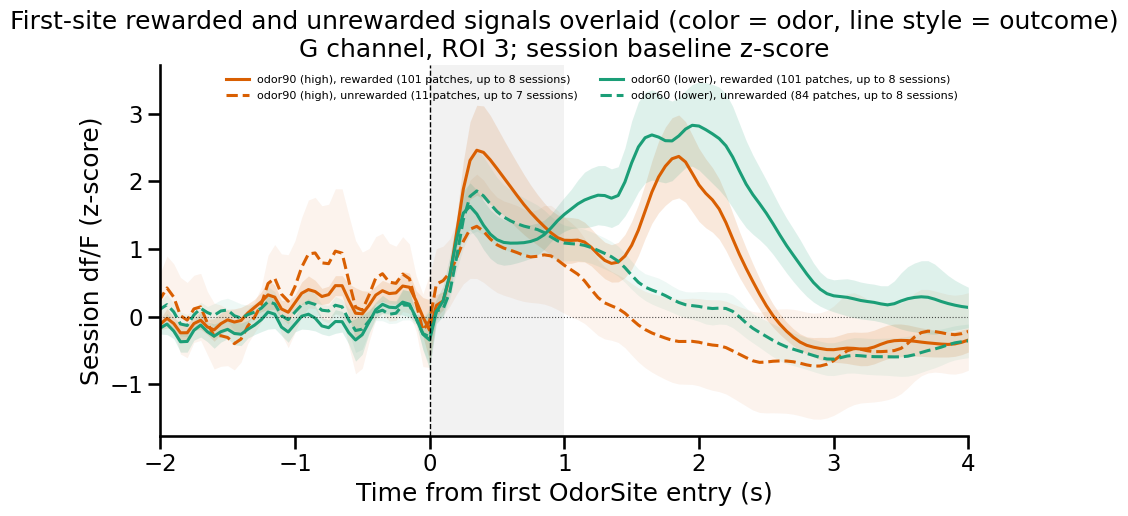

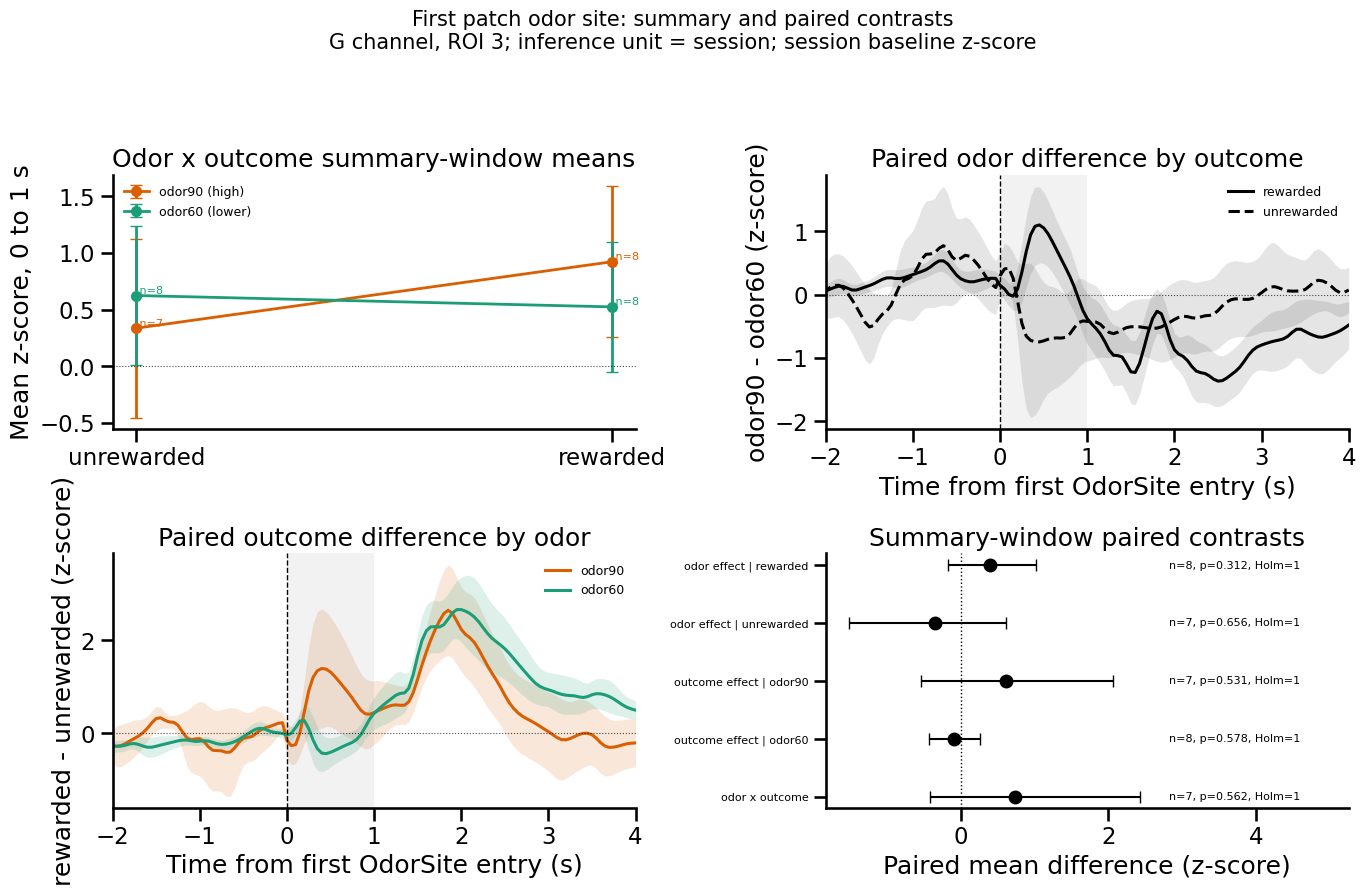

In [228]:
from IPython.display import display

first_odor_result = analyze_first_odor_value_signal(
    aligned=FIRST_ODOR_ALIGNED,
    epochs=FIRST_ODOR_EPOCHS,
    channel=FIRST_ODOR_CHANNEL,
    roi=FIRST_ODOR_ROI,
    baseline_window=FIRST_ODOR_BASELINE,
    summary_window=FIRST_ODOR_SUMMARY_WINDOW,
    xlim=FIRST_ODOR_XLIM,
    require_choice=FIRST_ODOR_REQUIRE_CHOICE,
    outcome_require_choice=FIRST_ODOR_OUTCOME_REQUIRE_CHOICE,
    inference_unit=FIRST_ODOR_INFERENCE_UNIT,
    source_column="value",
    normalization=FIRST_ODOR_NORMALIZATION,
    scale=FIRST_ODOR_SCALE,
    n_boot=FIRST_ODOR_N_BOOT,
    n_perm=FIRST_ODOR_N_PERM,
    seed=FIRST_ODOR_RANDOM_SEED,
)

# print(
#     "Session baseline statistics used for z-scoring "
#     f"({FIRST_ODOR_BASELINE[0]:g} to {FIRST_ODOR_BASELINE[1]:g} s)"
# )
# display(first_odor_result["session_baseline_stats"])

# print("Pooled first-site event counts after baseline QC")
# display(first_odor_result["counts"])

# print("Odor-label source check for the pooled analysis")
# label_source_check = (
#     first_odor_result["first_events"]
#     .groupby(
#         ["odor_condition", "odor_source_column", "odor_source_value"],
#         dropna=False,
#     )
#     .size()
#     .rename("n_events")
#     .reset_index()
# )
# display(label_source_check)

# print("Reward-outcome split QC")
# display(first_odor_result["outcome_qc"])

# print("First-site counts split by odor and reward outcome")
# display(
#     first_odor_result["outcome_counts"].sort_values(
#         ["reward_outcome", "odor_condition"]
#     )
# )

# print("Odor-label source check for the reward-outcome split")
# outcome_label_source_check = (
#     first_odor_result["outcome_first_events"]
#     .groupby(
#         [
#             "odor_condition",
#             "reward_outcome",
#             "odor_source_column",
#             "odor_source_value",
#         ],
#         dropna=False,
#     )
#     .size()
#     .rename("n_events")
#     .reset_index()
# )
# display(outcome_label_source_check)

# if not first_odor_result["reward_latency_summary"].empty:
#     print(
#         "Reward-latency QC (s from first OdorSite entry). For an expectation-only "
#         "summary, the gray window should ideally end before these latencies."
#     )
#     display(first_odor_result["reward_latency_summary"])

# print("Original pooled paired summary; positive difference means odor90 > odor60")
# display(first_odor_result["summary_stats"])

# print(
#     "Outcome-split paired summaries. The interaction is "
#     "(odor90 - odor60)_rewarded - (odor90 - odor60)_unrewarded."
# )
# display(first_odor_result["outcome_contrast_summary"])

# first_odor_fig, first_odor_axes = plot_first_odor_value_signal(first_odor_result)
# plt.show()

first_odor_reward_fig, first_odor_reward_axes = plot_first_odor_reward_split(
    first_odor_result
)
plt.show()


##Reward Ordinal analysis

In [167]:
#Reward Ordinal

# Keep only OdorSite choice epochs (events)
od_ev = epochs[
    (epochs["label"] == "OdorSite") &
    (epochs["is_choice"].astype(bool))
].copy()

# Define a patch identifier.
# Use what you have available; these are typical:
patch_id_cols = [c for c in ["mouse","session_id","patch_onset"] if c in od_ev.columns]
od_ev["patch_id"] = od_ev[patch_id_cols].astype(str).agg("|".join, axis=1)

# Reward ordinal within patch (only counts rewarded sites)
od_ev = od_ev.sort_values(["patch_id","epoch_time"])
od_ev["reward_ordinal"] = (
    od_ev.groupby("patch_id")["is_reward"]
    .transform(lambda s: s.astype(int).cumsum())
)

# Mark rewarded events only
od_reward = od_ev[od_ev["is_reward"].astype(bool)].copy()

# Optional: keep only ordinals up to N
MAX_ORD = 9
od_reward = od_reward[od_reward["reward_ordinal"].between(1, MAX_ORD)]
od_reward[["epoch_id","patch_id","reward_ordinal"]].head()


,epoch_id,patch_id,reward_ordinal
2,788731_2025-12-09_2,788731|2025-12-09|1380145.3696,1
6,788731_2025-12-09_6,788731|2025-12-09|1380145.3696,2
8,788731_2025-12-09_8,788731|2025-12-09|1380145.3696,3
10,788731_2025-12-09_10,788731|2025-12-09|1380145.3696,4
14,788731_2025-12-09_14,788731|2025-12-09|1380145.3696,5


In [171]:
CHANNEL = "R"   # "G" or "Ctrl"
ROI = 1
ALIGN = "OdorSite"     # or "InterSite"
BASELINE_WIN = (-2.0, 0.0)   # use (-2, 0) or (-2, -0.5), etc.

# Pull aligned rows for those rewarded epochs
p = aligned[
    (aligned["align_label"] == ALIGN) &
    (aligned["channel"] == CHANNEL) &
    (aligned["roi"] == ROI) &
    (aligned["epoch_id"].isin(od_reward["epoch_id"]))
].copy()

# Attach ordinal label
p = p.merge(od_reward[["epoch_id","reward_ordinal"]], on="epoch_id", how="left")

# Baseline per epoch
b0, b1 = BASELINE_WIN
pre = p[(p["t_rel"] >= b0) & (p["t_rel"] < b1)]
base = pre.groupby("epoch_id")["value"].mean().rename("baseline")

p = p.join(base, on="epoch_id").dropna(subset=["baseline"])
p["value_bs"] = p["value"] - p["baseline"]


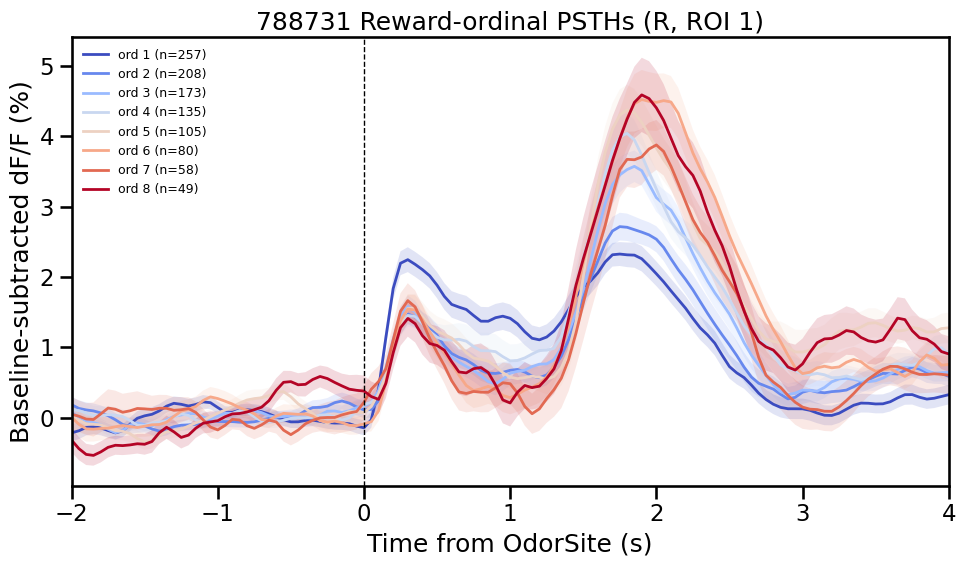

In [172]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Aggregate: (ordinal, t_rel) -> mean, SEM
grp = p.groupby(["reward_ordinal", "t_rel"])["value_bs"]
stats = grp.agg(mean="mean", n="count", std="std").reset_index()
stats["sem"] = stats["std"] / np.sqrt(stats["n"])

fig, ax = plt.subplots(figsize=(10, 6))

# Ordinal 1 = blue, highest ordinal = red
cmap = mpl.colormaps["coolwarm"]
norm = mpl.colors.Normalize(vmin=1, vmax=MAX_ORD)

for k in range(1, MAX_ORD + 1):
    s = stats.loc[stats["reward_ordinal"] == k].sort_values("t_rel")

    if s.empty:
        continue

    color = cmap(norm(k))
    t = s["t_rel"].to_numpy()
    mean = s["mean"].to_numpy() * 100
    sem = s["sem"].to_numpy() * 100

    ax.plot(
        t,
        mean,
        color=color,
        linewidth=2,
        label=f"ord {k} (n={int(s['n'].max())})",
    )

    ax.fill_between(
        t,
        mean - sem,
        mean + sem,
        color=color,
        alpha=0.15,
        linewidth=0,
    )

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlim(-2, 4)
ax.set_xlabel(f"Time from {ALIGN} (s)")
ax.set_ylabel("Baseline-subtracted dF/F (%)")
ax.set_title(f"{SUBJ_ID} Reward-ordinal PSTHs ({CHANNEL}, ROI {ROI})")

ax.legend(
    loc="upper left",
    fontsize=9,
    frameon=False,
)

fig.tight_layout()
plt.show()

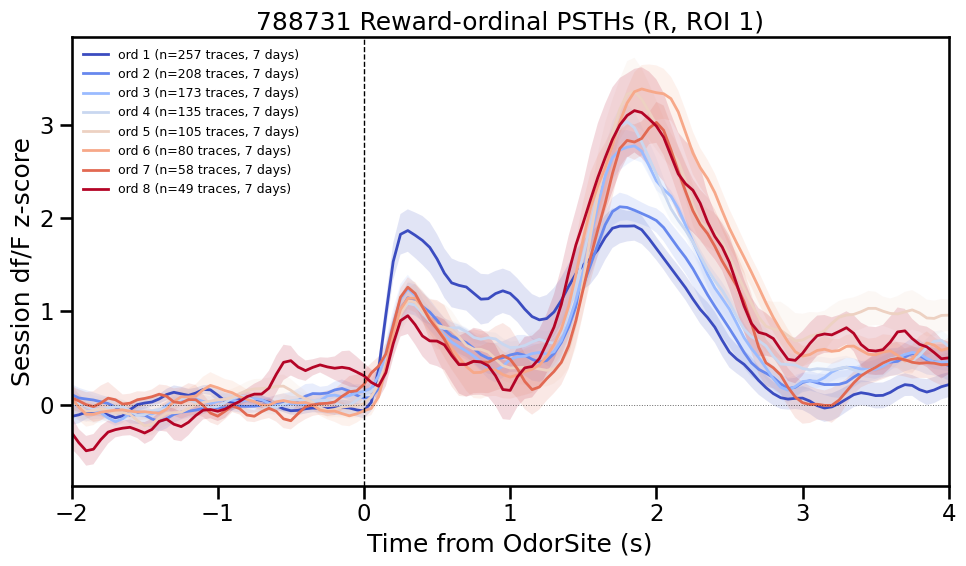

In [173]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
Z_BASELINE = (-2, 0)  # baseline window used for session z-scoring
SESSION_COL = "session_id"
SOURCE_COL = "value_bs"
MAX_ORD = 8

# p should already be filtered to the desired mouse, ROI, channel, etc.
p_z = p.copy()

# Number of valid traces and contributing sessions for each ordinal
counts_per_ordinal = (
    p_z[
        [SESSION_COL, "epoch_id", "reward_ordinal"]
    ]
    .drop_duplicates()
    .groupby("reward_ordinal")
    .agg(
        n_traces=("epoch_id", "size"),
        n_sessions=(SESSION_COL, "nunique"),
    )
    .to_dict("index")
)

# ------------------------------------------------------------
# 1. Calculate baseline mean and SD separately for each session
# ------------------------------------------------------------
baseline_mask = (
    (p_z["t_rel"] >= Z_BASELINE[0])
    & (p_z["t_rel"] < Z_BASELINE[1])
)

session_zstats = (
    p_z.loc[baseline_mask]
    .groupby(SESSION_COL)[SOURCE_COL]
    .agg(
        baseline_mean="mean",
        baseline_std="std",
        baseline_n="count",
    )
)

p_z = p_z.join(session_zstats, on=SESSION_COL)

# Remove sessions whose baseline SD cannot be calculated
valid_z = (
    p_z["baseline_std"].notna()
    & np.isfinite(p_z["baseline_std"])
    & (p_z["baseline_std"] > 0)
)

excluded_sessions = p_z.loc[~valid_z, SESSION_COL].unique()

if len(excluded_sessions):
    print(
        "Excluded sessions with missing or zero baseline SD:",
        excluded_sessions,
    )

p_z = p_z.loc[valid_z].copy()

# Session-normalized signal
p_z["value_z_session"] = (
    p_z[SOURCE_COL] - p_z["baseline_mean"]
) / p_z["baseline_std"]

# ------------------------------------------------------------
# 2. Average trials within each session first
# ------------------------------------------------------------
session_psth = (
    p_z.groupby(
        [SESSION_COL, "reward_ordinal", "t_rel"],
        as_index=False,
    )["value_z_session"]
    .mean()
)

# ------------------------------------------------------------
# 3. Average session PSTHs across days
# ------------------------------------------------------------
stats_z = (
    session_psth
    .groupby(["reward_ordinal", "t_rel"])["value_z_session"]
    .agg(
        mean="mean",
        n_sessions="count",
        std="std",
    )
    .reset_index()
)

stats_z["sem"] = (
    stats_z["std"]
    / np.sqrt(stats_z["n_sessions"])
)

# Number of contributing sessions for each ordinal
sessions_per_ordinal = (
    session_psth
    .groupby("reward_ordinal")[SESSION_COL]
    .nunique()
    .to_dict()
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

cmap = mpl.colormaps["coolwarm"]
norm = mpl.colors.Normalize(vmin=1, vmax=MAX_ORD)

for k in range(1, MAX_ORD + 1):
    s = (
        stats_z.loc[stats_z["reward_ordinal"] == k]
        .sort_values("t_rel")
    )

    if s.empty:
        continue

    color = cmap(norm(k))

    t = s["t_rel"].to_numpy()
    mean = s["mean"].to_numpy()
    sem = s["sem"].to_numpy()

    counts = counts_per_ordinal.get(
        k,
        {"n_traces": 0, "n_sessions": 0},
    )

    n_traces = counts["n_traces"]
    n_sessions = counts["n_sessions"]

    ax.plot(
        t,
        mean,
        color=color,
        linewidth=2,
        label=f"ord {k} (n={n_traces} traces, {n_sessions} days)",
    )

    ax.fill_between(
        t,
        mean - sem,
        mean + sem,
        color=color,
        alpha=0.15,
        linewidth=0,
    )

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.axhline(
    0,
    color="black",
    linestyle=":",
    linewidth=0.7,
    alpha=0.6,
)

ax.set_xlim(-2, 4)
ax.set_xlabel(f"Time from {ALIGN} (s)")
ax.set_ylabel("Session df/F z-score")
ax.set_title(
    f"{SUBJ_ID} Reward-ordinal PSTHs ({CHANNEL}, ROI {ROI})"
)

ax.legend(
    loc="upper left",
    fontsize=9,
    frameon=False,
)

fig.tight_layout()
plt.show()

In [50]:
##Conseuctive failures x Cumulative Rewards

state = epochs[[
    "epoch_id",
    "consecutive_failures",
    "cumulative_failures",
    "cumulative_rewards",
    "consecutive_rewards",
    "after_choice_cumulative_rewards",
    "patch_number",
    "mouse",
    "session_id",
    "label",
    "is_choice",
    "is_reward",
]].drop_duplicates("epoch_id")

aligned2 = aligned.merge(state, on="epoch_id", how="left", suffixes=("", "_epoch"))


In [51]:
##Conseuctive failures x Cumulative Rewards
baseline_lo, baseline_hi = -2.0, 0.0  # seconds

# baseline mask
is_base = (aligned2["t_rel"] >= baseline_lo) & (aligned2["t_rel"] < baseline_hi)

# mean baseline per (epoch_id, roi, channel)
baseline = (
    aligned2.loc[is_base]
    .groupby(["epoch_id", "roi", "channel"], sort=False)["value"]
    .mean()
    .rename("baseline")
    .reset_index()
)

aligned2 = aligned2.merge(baseline, on=["epoch_id", "roi", "channel"], how="left")
aligned2["value_bs"] = aligned2["value"] - aligned2["baseline"]


In [59]:
# Failures
aligned2["fail_bin"] = pd.cut(
    aligned2["consecutive_failures"],
    bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 100],
    labels=["0", "1", "2", "3", "4", "5","6","7","8"],
)

# Cumulative rewards
aligned2["rew_bin"] = pd.cut(
    aligned2["cumulative_rewards"],
    bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 100],
    labels=["0", "1", "2", "3", "4", "5","6","7","8"],
)


In [60]:
tmp = aligned2.query("align_label == 'OdorSite' and is_reward == 1").copy()
tmp = tmp.dropna(subset=["fail_bin", "rew_bin", "value_bs", "t_rel"])

mean_trace = (
    tmp.groupby(["channel", "roi", "fail_bin", "rew_bin", "t_rel"], sort=False)["value_bs"]
    .mean()
    .reset_index()
)

mean_trace_z = (
    tmp.groupby(["channel", "roi", "fail_bin", "rew_bin", "t_rel"], sort=False)["value_z"]
    .mean()
    .reset_index()
)

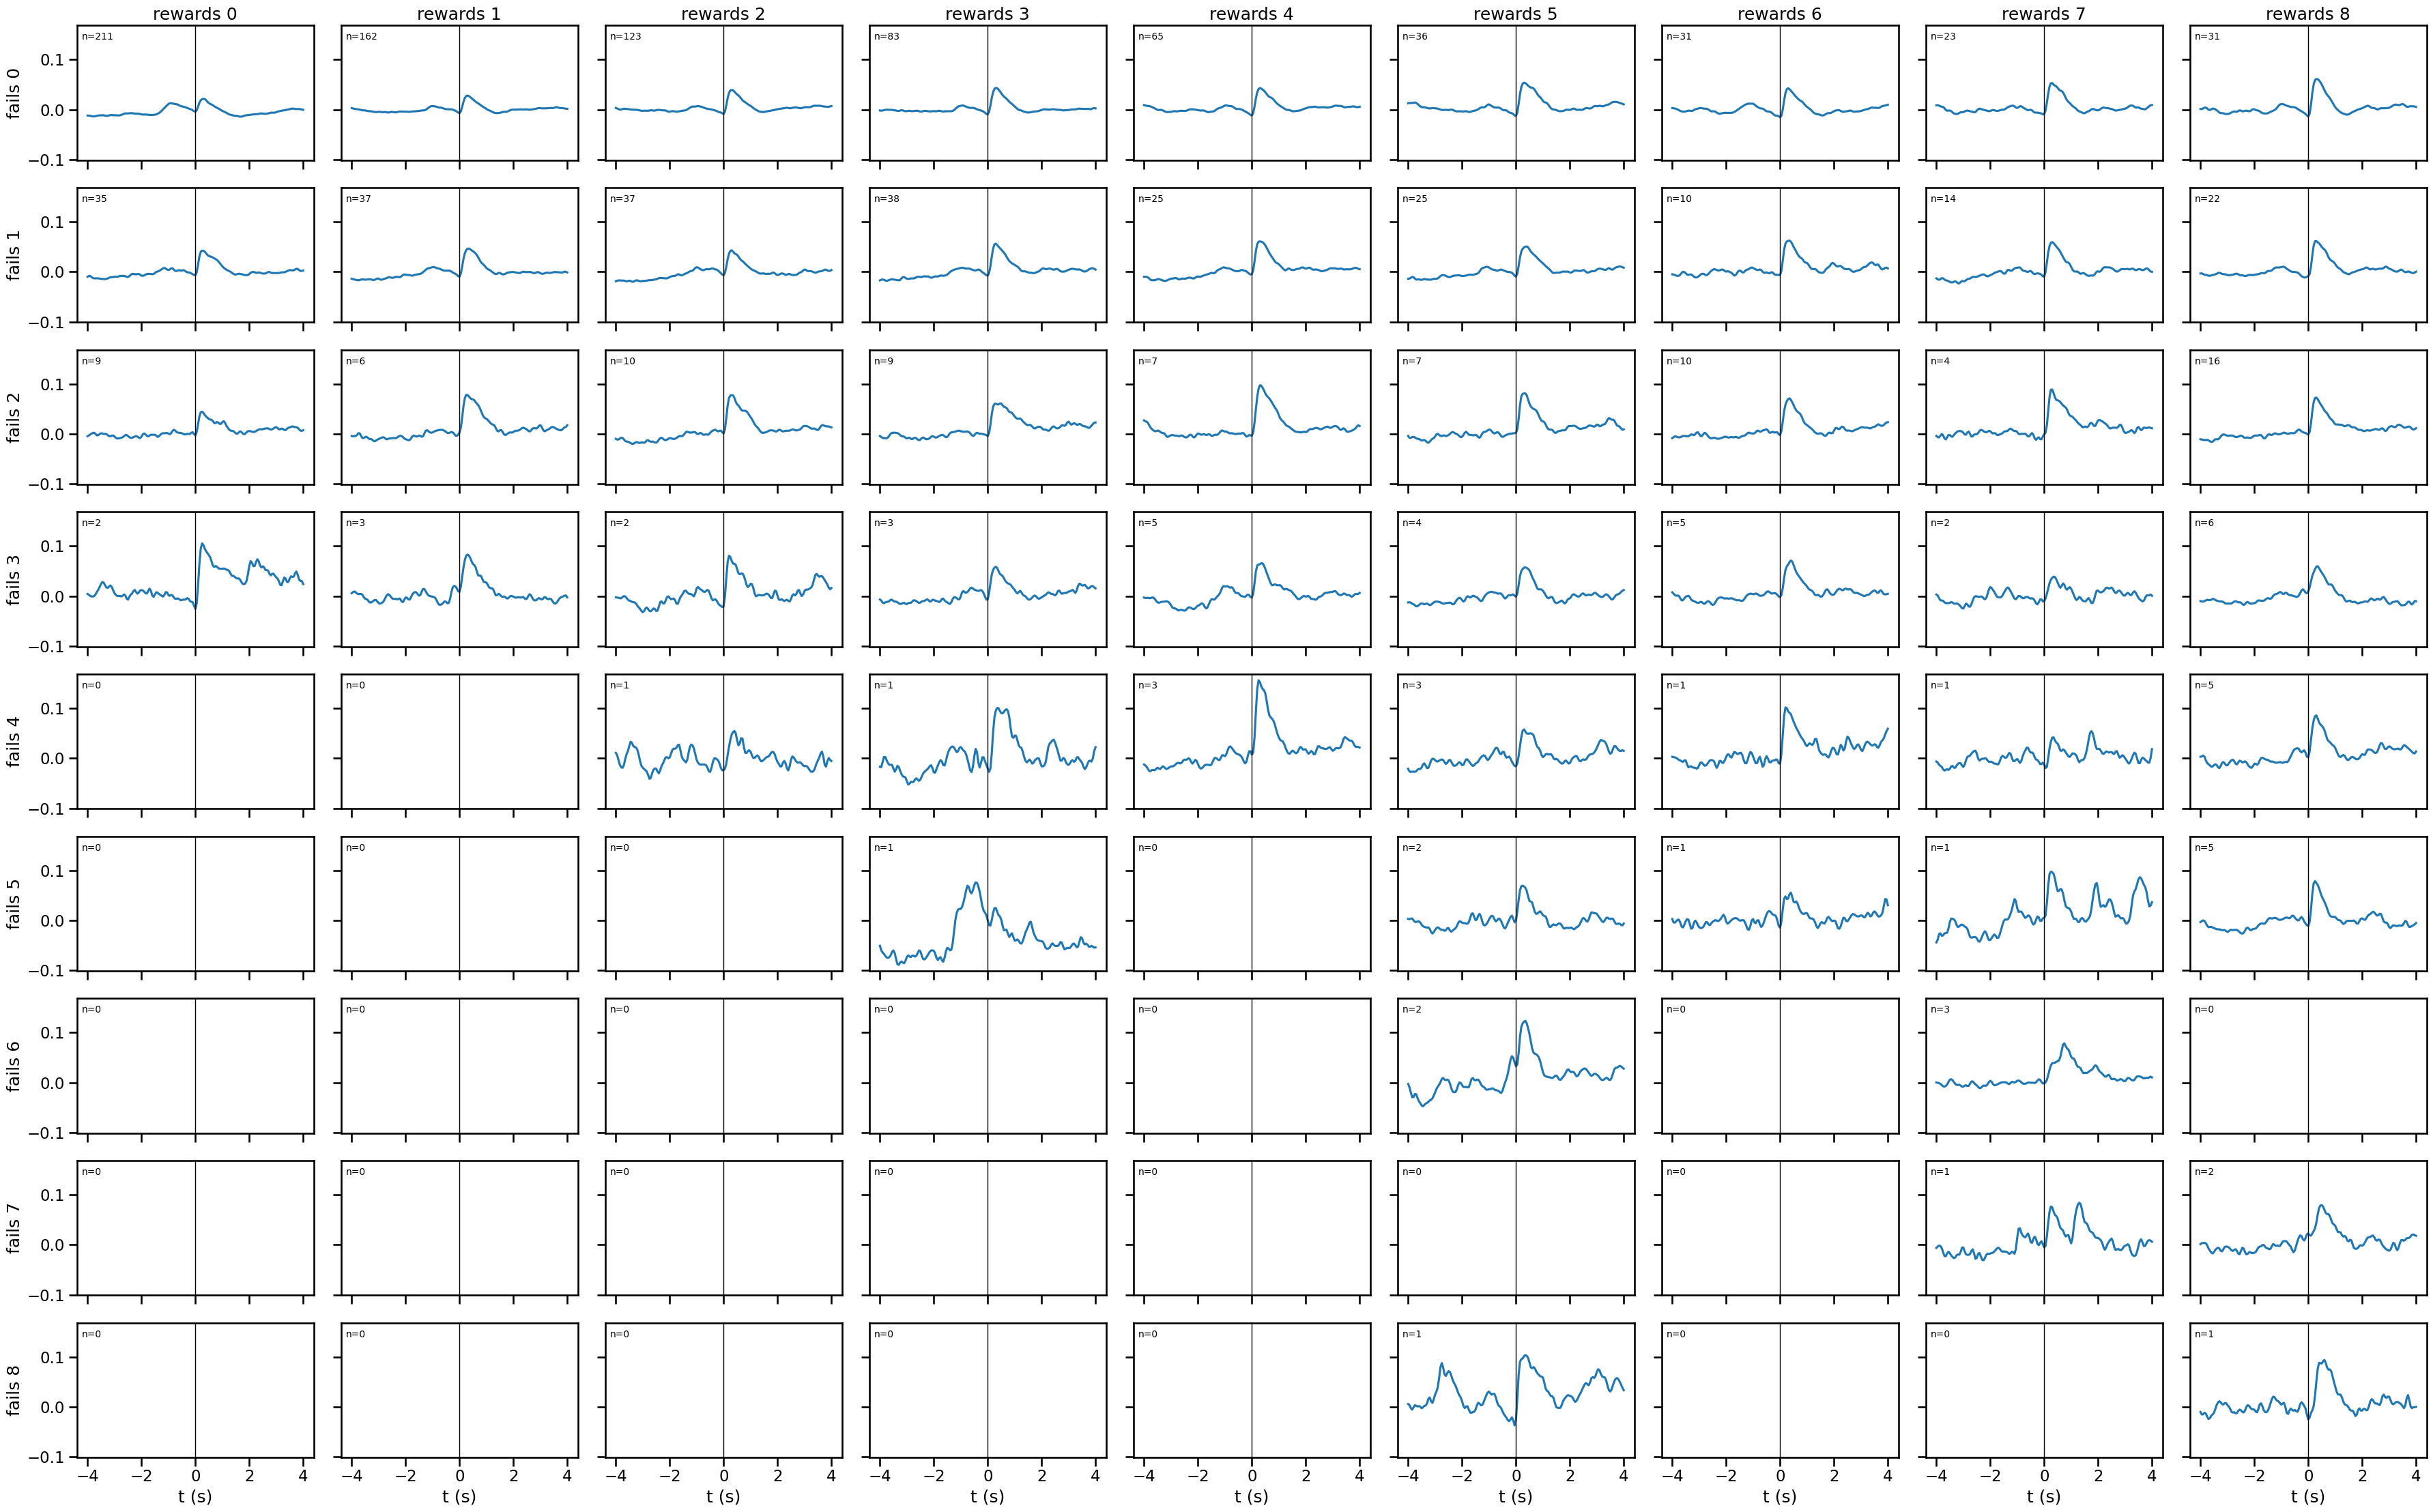

In [61]:
import matplotlib.pyplot as plt

channel = "R"
roi = 1

mt = mean_trace.query("channel == @channel and roi == @roi").copy()

fail_levels = list(mt["fail_bin"].cat.categories)
rew_levels  = list(mt["rew_bin"].cat.categories)

# --- compute N events per grid cell from the *event-level* table, not mean_trace ---
# Use the underlying aligned/per-epoch data you averaged to make mean_trace.
# Assuming you have `tmp` (or `aligned2`) with epoch_id, fail_bin, rew_bin, channel, roi.
counts = (
    tmp.query("channel == @channel and roi == @roi")
       .dropna(subset=["fail_bin","rew_bin"])
       .groupby(["fail_bin","rew_bin"])["epoch_id"]
       .nunique()
       .reindex(pd.MultiIndex.from_product([fail_levels, rew_levels], names=["fail_bin","rew_bin"]))
       .fillna(0)
       .astype(int)
)

fig, axes = plt.subplots(len(fail_levels), len(rew_levels),
                         figsize=(4*len(rew_levels), 2.5*len(fail_levels)),
                         sharex=True, sharey=True)

for i, f in enumerate(fail_levels):
    for j, r in enumerate(rew_levels):
        ax = axes[i, j]
        cell = mt[(mt["fail_bin"] == f) & (mt["rew_bin"] == r)]
        n = int(counts.loc[(f, r)])  # number of unique epoch_ids in this cell

        if not cell.empty:
            cell = cell.sort_values("t_rel")
            ax.plot(cell["t_rel"].to_numpy(), cell["value_bs"].to_numpy())

        ax.axvline(0, color="k", linewidth=1)

        # write N in axes coordinates (top-left)
        ax.text(
            0.02, 0.95, f"n={n}",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=10
        )

        if i == 0: ax.set_title(f"rewards {r}")
        if j == 0: ax.set_ylabel(f"fails {f}")
        if i == len(fail_levels)-1: ax.set_xlabel("t (s)")

plt.tight_layout()
plt.show()



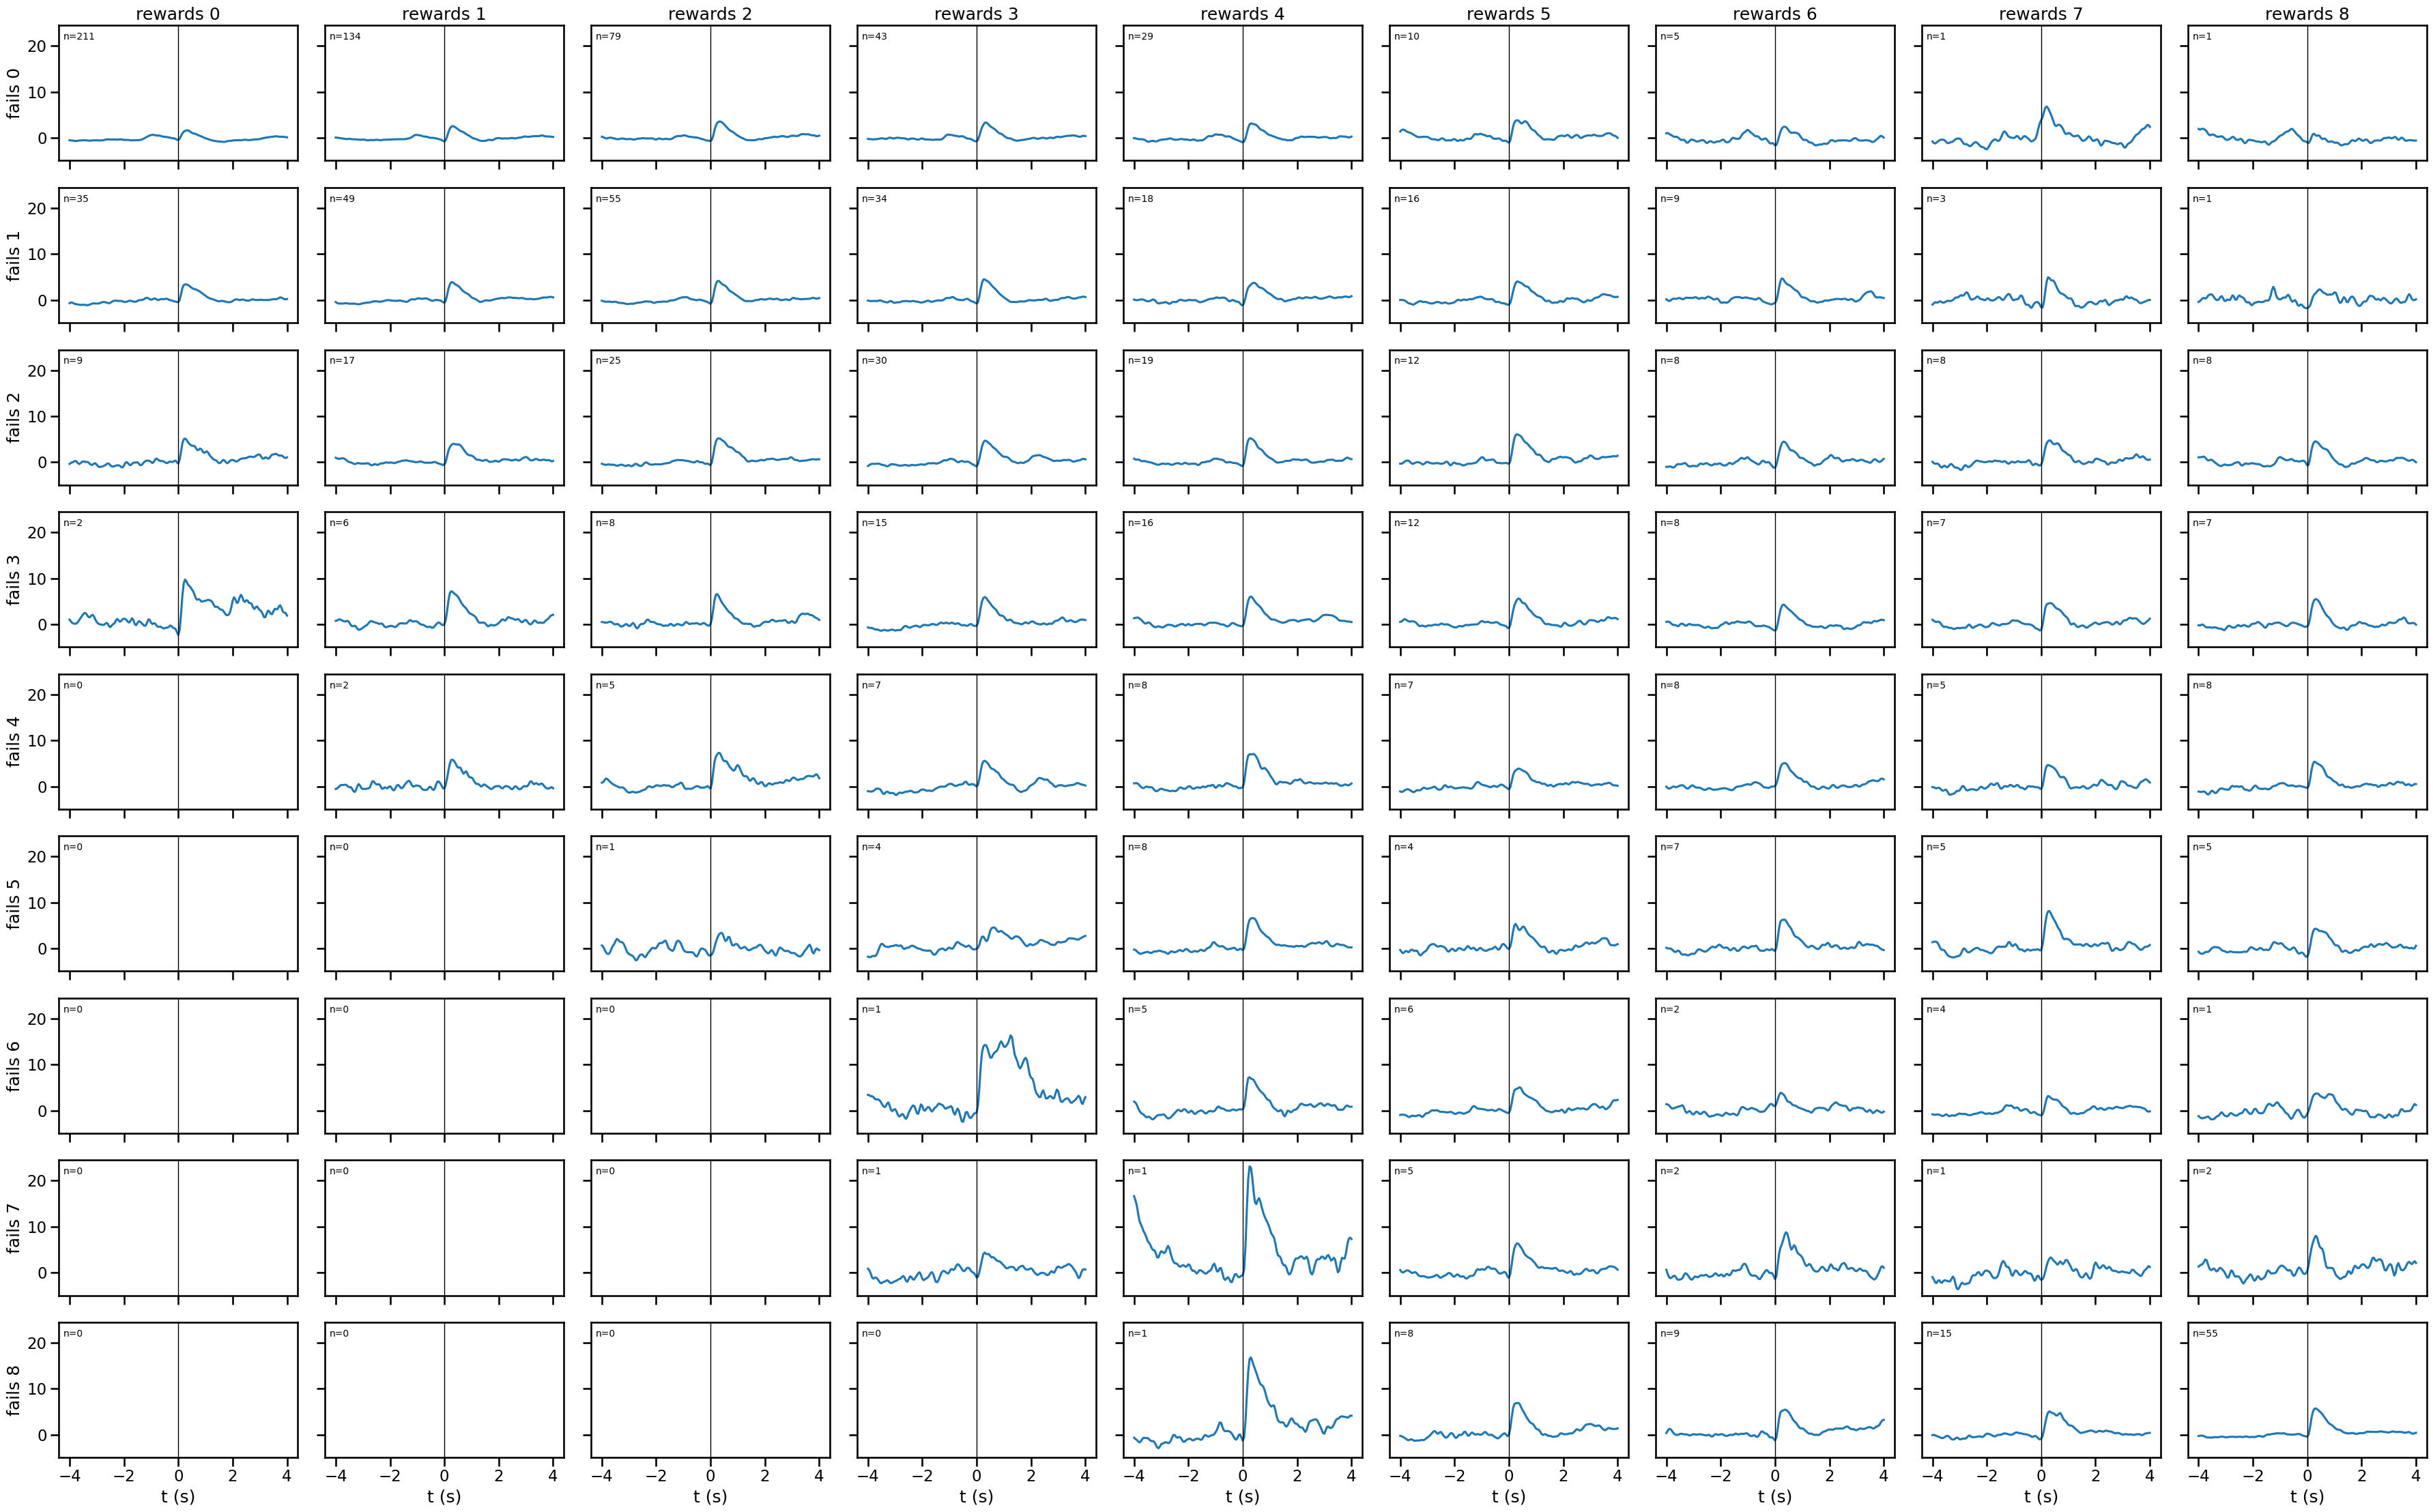

In [58]:
#Z-score, rewardONset version
import matplotlib.pyplot as plt

channel = "R"
roi = 1

mt = mean_trace_z.query("channel == @channel and roi == @roi").copy()

fail_levels = list(mt["fail_bin"].cat.categories)
rew_levels  = list(mt["rew_bin"].cat.categories)

# --- compute N events per grid cell from the *event-level* table, not mean_trace ---
# Use the underlying aligned/per-epoch data you averaged to make mean_trace.
# Assuming you have `tmp` (or `aligned2`) with epoch_id, fail_bin, rew_bin, channel, roi.
counts = (
    tmp.query("channel == @channel and roi == @roi")
       .dropna(subset=["fail_bin","rew_bin"])
       .groupby(["fail_bin","rew_bin"])["epoch_id"]
       .nunique()
       .reindex(pd.MultiIndex.from_product([fail_levels, rew_levels], names=["fail_bin","rew_bin"]))
       .fillna(0)
       .astype(int)
)

fig, axes = plt.subplots(len(fail_levels), len(rew_levels),
                         figsize=(4*len(rew_levels), 2.5*len(fail_levels)),
                         sharex=True, sharey=True)

for i, f in enumerate(fail_levels):
    for j, r in enumerate(rew_levels):
        ax = axes[i, j]
        cell = mt[(mt["fail_bin"] == f) & (mt["rew_bin"] == r)]
        n = int(counts.loc[(f, r)])  # number of unique epoch_ids in this cell

        if not cell.empty:
            cell = cell.sort_values("t_rel")
            ax.plot(cell["t_rel"].to_numpy(), cell["value_z"].to_numpy())

        ax.axvline(0, color="k", linewidth=1)

        # write N in axes coordinates (top-left)
        ax.text(
            0.02, 0.95, f"n={n}",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=10
        )

        if i == 0: ax.set_title(f"rewards {r}")
        if j == 0: ax.set_ylabel(f"fails {f}")
        if i == len(fail_levels)-1: ax.set_xlabel("t (s)")

plt.tight_layout()
plt.show()

In [41]:
aligned_long.columns
mean_trace.columns

Index(['channel', 'roi', 'fail_bin', 'rew_bin', 't_rel', 'value_bs'], dtype='object')